# A Diffusion Models

## Investigating the dataset

As dataset we use Fashion-MNIST, which consists of 60,000 training images and 10,000 test images of clothing items such as shirts, trousers, shoes, bags, and more. Let's see if this is enough to get good results ;-)

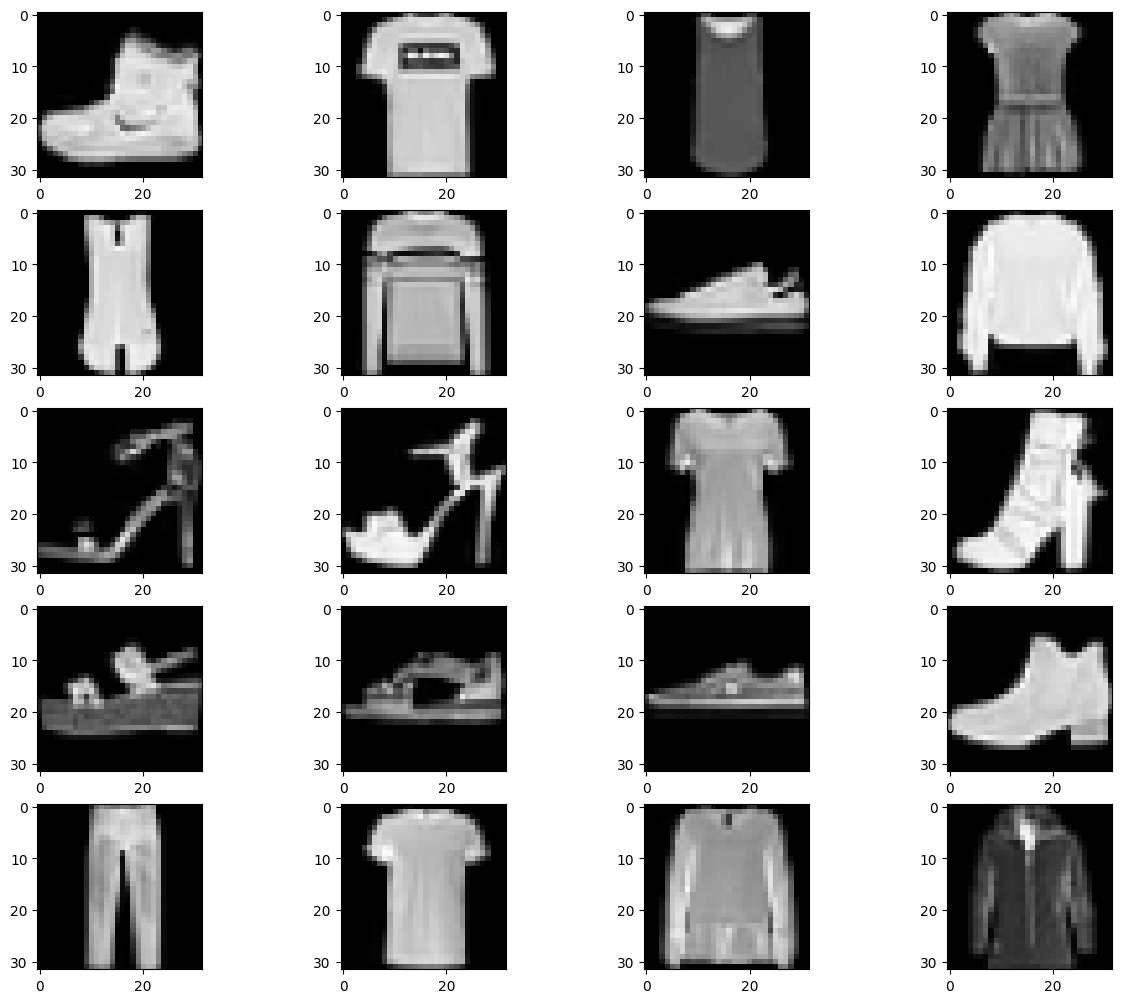

In [19]:
import torch
import torchvision
import matplotlib.pyplot as plt
from torchvision import transforms

def show_images(dataset, num_samples=20, cols=4):
    plt.figure(figsize=(15,15))
    for i, img in enumerate(dataset):
        if i == num_samples:
            break
        plt.subplot(int(num_samples/cols) + 1, cols, i + 1)
        plt.imshow(img[0].permute(1, 2, 0))

preview_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

data = torchvision.datasets.FashionMNIST(
    root=".",
    train=True,
    download=True,
    transform=preview_transform
)

show_images(data)

Later in this notebook we will do some additional modifications to this dataset, for example make the images smaller, convert them to tensors ect.

# Building the Diffusion Model


## Step 1: The forward process = Noise scheduler




We first need to build the inputs for our model, which are progressively noisier versions of Fashion-MNIST images. Instead of doing this sequentially, we can use the closed form provided in the papers to calculate the image for any of the timesteps individually.

**Key Takeaways**:
- The noise-levels/variances can be pre-computed
- There are different types of variance schedules
- We can sample each timestep image independently (Sums of Gaussians is also Gaussian)
- No model is needed in this forward step

In [20]:
import torch.nn.functional as F
import math

def cosine_beta_schedule(timesteps, s=0.008):
    """
    Cosine schedule from Nichol & Dhariwal (2021).
    Adds noise more gradually than the linear schedule.
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clamp(betas, 0.0001, 0.9999)

def get_index_from_list(vals, t, x_shape):
    """
    Returns a specific index t of a passed list of values vals
    while considering the batch dimension.
    """
    batch_size = t.shape[0]
    out = vals.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

def forward_diffusion_sample(x_0, t, device="cpu"):
    """
    Takes an image and a timestep as input and
    returns the noisy version of it
    """
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x_0.shape
    )
    # mean + variance
    return sqrt_alphas_cumprod_t.to(device) * x_0.to(device) \
    + sqrt_one_minus_alphas_cumprod_t.to(device) * noise.to(device), noise.to(device)


# Define beta schedule
T = 200
betas = cosine_beta_schedule(timesteps=T)

# Pre-calculate different terms for closed form
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)

Let's test it on our dataset ...

In [21]:
from torchvision import transforms
from torch.utils.data import DataLoader
import numpy as np

IMG_SIZE = 32
BATCH_SIZE = 64

def load_transformed_dataset():
    data_transforms = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Lambda(lambda t: (t * 2) - 1)
    ]

    data_transform = transforms.Compose(data_transforms)

    train = torchvision.datasets.FashionMNIST(
        root=".",
        train=True,
        download=True,
        transform=data_transform
    )

    test = torchvision.datasets.FashionMNIST(
        root=".",
        train=False,
        download=True,
        transform=data_transform
    )

    return torch.utils.data.ConcatDataset([train, test])


def show_tensor_image(image):
    reverse_transforms = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1) / 2),
        transforms.Lambda(lambda t: t.permute(1, 2, 0)),
        transforms.Lambda(lambda t: t * 255.),
        transforms.Lambda(lambda t: t.numpy().astype(np.uint8)),
        transforms.ToPILImage(),
    ])

    if len(image.shape) == 4:
        image = image[0, :, :, :]

    plt.imshow(reverse_transforms(image))


data = load_transformed_dataset()
dataloader = DataLoader(data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)


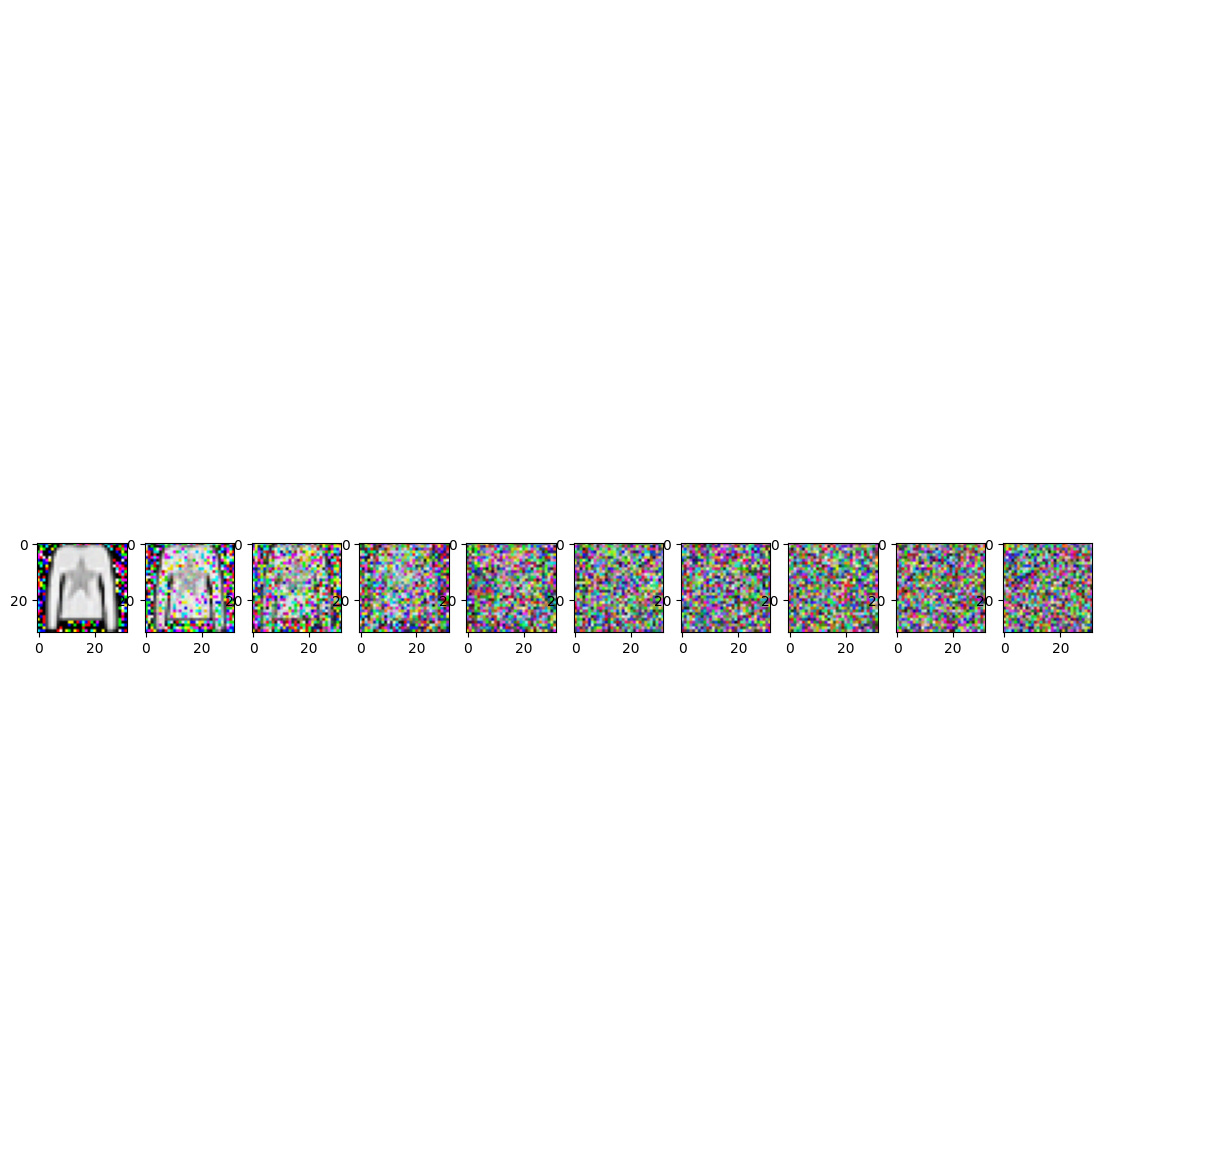

In [22]:
# Simulate forward diffusion
image = next(iter(dataloader))[0]

plt.figure(figsize=(15,15))
plt.axis('off')
num_images = 10
stepsize = int(T/num_images)

for idx in range(0, T, stepsize):
    t = torch.Tensor([idx]).type(torch.int64)
    plt.subplot(1, num_images+1, int(idx/stepsize) + 1)
    img, noise = forward_diffusion_sample(image, t)
    show_tensor_image(img)

## Step 2: The backward process = U-Net



For a great introduction to UNets, have a look at this post: https://amaarora.github.io/2020/09/13/unet.html.


**Key Takeaways**:
- We use a simple form of a UNet for to predict the noise in the image
- The input is a noisy image, the ouput the noise in the image
- Because the parameters are shared accross time, we need to tell the network in which timestep we are
- The Timestep is encoded by the transformer Sinusoidal Embedding
- We output one single value (mean), because the variance is fixed


In [23]:
from torch import nn
import math


class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        # GroupNorm is more stable than BatchNorm for varying batch sizes
        self.gnorm1 = nn.GroupNorm(8, out_ch)
        self.gnorm2 = nn.GroupNorm(8, out_ch)
        self.relu = nn.ReLU()

    def forward(self, x, t):
        # First Conv
        h = self.gnorm1(self.relu(self.conv1(x)))
        # Time embedding
        time_emb = self.relu(self.time_mlp(t))
        # Extend last 2 dimensions
        time_emb = time_emb[(..., ) + (None, ) * 2]
        # Add time channel
        h = h + time_emb
        # Second Conv
        h = self.gnorm2(self.relu(self.conv2(h)))
        # Down or Upsample
        return self.transform(h)


class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class SimpleUnet(nn.Module):
    """
    A simplified variant of the Unet architecture.
    """
    def __init__(self):
        super().__init__()
        image_channels = 3
        down_channels = (64, 128, 256, 512)
        up_channels   = (512, 256, 128, 64)
        out_dim = 3
        time_emb_dim = 32

        # Time embedding
        self.time_mlp = nn.Sequential(
                SinusoidalPositionEmbeddings(time_emb_dim),
                nn.Linear(time_emb_dim, time_emb_dim),
                nn.ReLU()
            )

        # Initial projection
        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)

        # Downsample
        self.downs = nn.ModuleList([Block(down_channels[i], down_channels[i+1],
                                    time_emb_dim)
                    for i in range(len(down_channels)-1)])
        # Upsample
        self.ups = nn.ModuleList([Block(up_channels[i], up_channels[i+1],
                                        time_emb_dim, up=True)
                    for i in range(len(up_channels)-1)])

        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, timestep):
        # Embed time
        t = self.time_mlp(timestep)
        # Initial conv
        x = self.conv0(x)
        # Unet
        residual_inputs = []
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x)
        for up in self.ups:
            residual_x = residual_inputs.pop()
            # Add residual x as additional channels
            x = torch.cat((x, residual_x), dim=1)
            x = up(x, t)
        return self.output(x)

model = SimpleUnet()
print("Num params: ", sum(p.numel() for p in model.parameters()))
model

Num params:  15453667


SimpleUnet(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=32, out_features=32, bias=True)
    (2): ReLU()
  )
  (conv0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downs): ModuleList(
    (0): Block(
      (time_mlp): Linear(in_features=32, out_features=128, bias=True)
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (transform): Conv2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (gnorm1): GroupNorm(8, 128, eps=1e-05, affine=True)
      (gnorm2): GroupNorm(8, 128, eps=1e-05, affine=True)
      (relu): ReLU()
    )
    (1): Block(
      (time_mlp): Linear(in_features=32, out_features=256, bias=True)
      (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (transform): Conv2d(256, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      


**Further improvements that can be implemented:**
- Residual connections
- Different activation functions like SiLU, GWLU, ...
- BatchNormalization
- GroupNormalization
- Attention
- ...

## Step 3: The loss



**Key Takeaways:**
- After some maths we end up with a very simple loss function
- There are other possible choices like L2 loss ect.


In [24]:
def get_loss(model, x_0, t):
    x_noisy, noise = forward_diffusion_sample(x_0, t, device)
    noise_pred = model(x_noisy, t)
    return F.l1_loss(noise, noise_pred)

## Sampling
- Without adding @torch.no_grad() we quickly run out of memory, because pytorch tacks all the previous images for gradient calculation
- Because we pre-calculated the noise variances for the forward pass, we also have to use them when we sequentially perform the backward process

In [25]:
@torch.no_grad()
def sample_timestep(x, t):
    """
    Calls the model to predict the noise in the image and returns
    the denoised image.
    Applies noise to this image, if we are not in the last step yet.
    """
    betas_t = get_index_from_list(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod, t, x.shape
    )
    sqrt_recip_alphas_t = get_index_from_list(sqrt_recip_alphas, t, x.shape)

    # Call model (current image - noise prediction)
    model_mean = sqrt_recip_alphas_t * (
        x - betas_t * model(x, t) / sqrt_one_minus_alphas_cumprod_t
    )
    posterior_variance_t = get_index_from_list(posterior_variance, t, x.shape)

    if t == 0:
        # As pointed out by Luis Pereira
        # The t's are offset from the t's in the paper
        return model_mean
    else:
        noise = torch.randn_like(x)
        return model_mean + torch.sqrt(posterior_variance_t) * noise

@torch.no_grad()
def sample_plot_image():
    # Sample noise
    img_size = IMG_SIZE
    img = torch.randn((1, 3, img_size, img_size), device=device)
    plt.figure(figsize=(15,15))
    plt.axis('off')
    num_images = 10
    stepsize = int(T/num_images)

    for i in range(0,T)[::-1]:
        t = torch.full((1,), i, device=device, dtype=torch.long)
        img = sample_timestep(img, t)
        # Edit: This is to maintain the natural range of the distribution
        img = torch.clamp(img, -1.0, 1.0)
        if i % stepsize == 0:
            plt.subplot(1, num_images, int(i/stepsize)+1)
            show_tensor_image(img.detach().cpu())
    plt.show()


Starting Epoch 1/20
Epoch 1 | Step 0 | Loss: 0.8077
Epoch 1 | Step 100 | Loss: 0.2286
Epoch 1 | Step 200 | Loss: 0.1939
Epoch 1 | Step 300 | Loss: 0.1450
Epoch 1 | Step 400 | Loss: 0.1216
Epoch 1 | Step 500 | Loss: 0.1420
Epoch 1 | Step 600 | Loss: 0.1308
Epoch 1 | Step 700 | Loss: 0.1153
Epoch 1 | Step 800 | Loss: 0.1103
Epoch 1 | Step 900 | Loss: 0.1220
Epoch 1 | Step 1000 | Loss: 0.1257


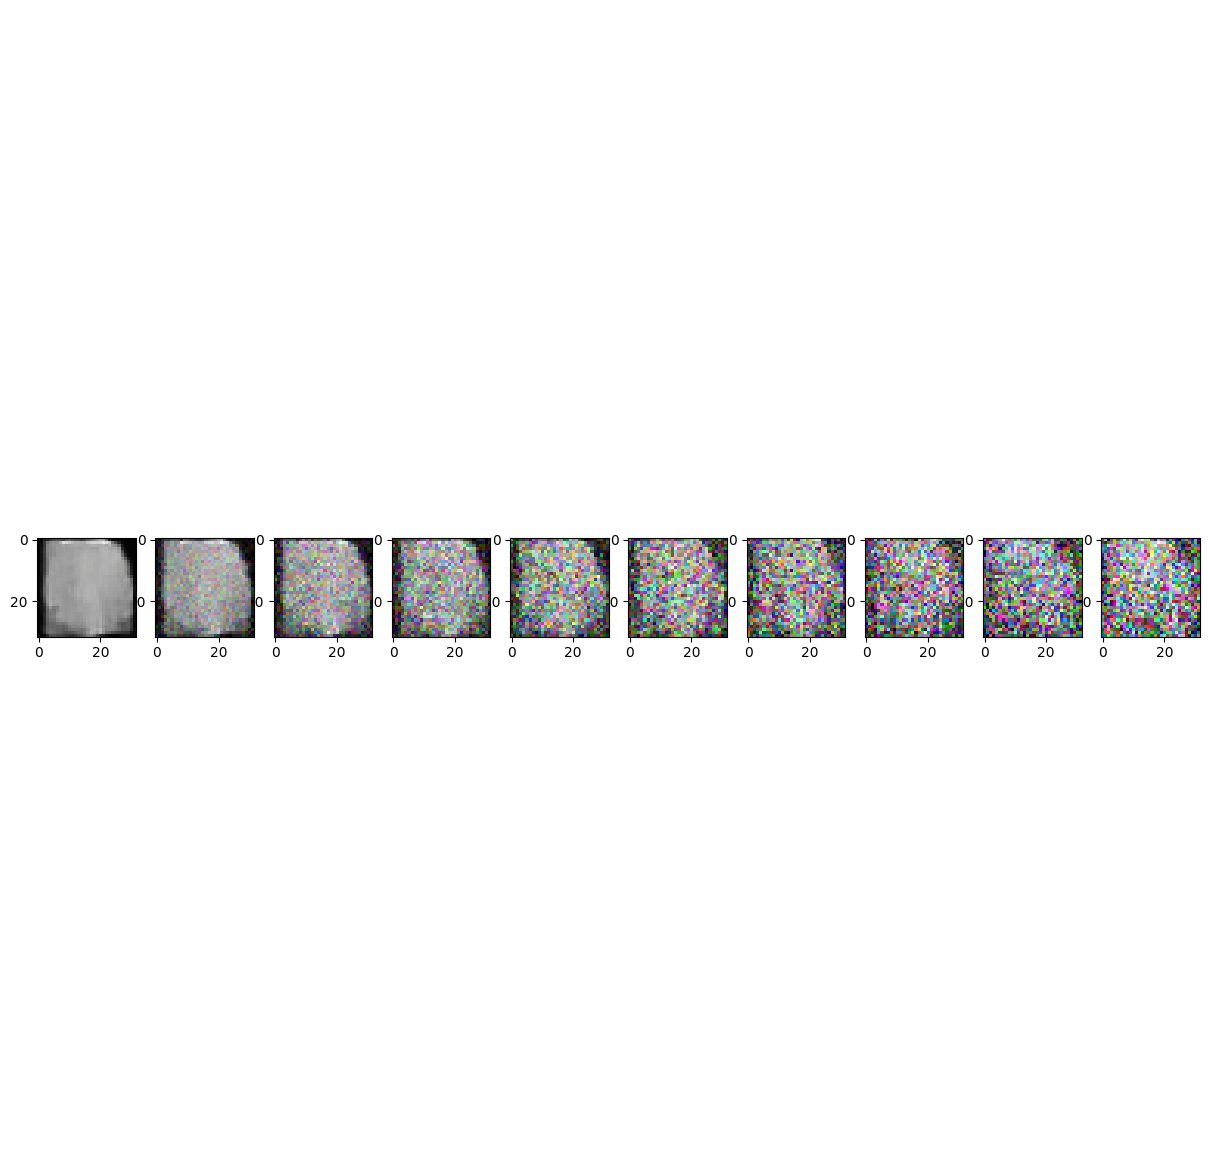


Starting Epoch 2/20
Epoch 2 | Step 0 | Loss: 0.1148
Epoch 2 | Step 100 | Loss: 0.1211
Epoch 2 | Step 200 | Loss: 0.1193
Epoch 2 | Step 300 | Loss: 0.1060
Epoch 2 | Step 400 | Loss: 0.1102
Epoch 2 | Step 500 | Loss: 0.1106
Epoch 2 | Step 600 | Loss: 0.1143
Epoch 2 | Step 700 | Loss: 0.1102
Epoch 2 | Step 800 | Loss: 0.0988
Epoch 2 | Step 900 | Loss: 0.1085
Epoch 2 | Step 1000 | Loss: 0.1164


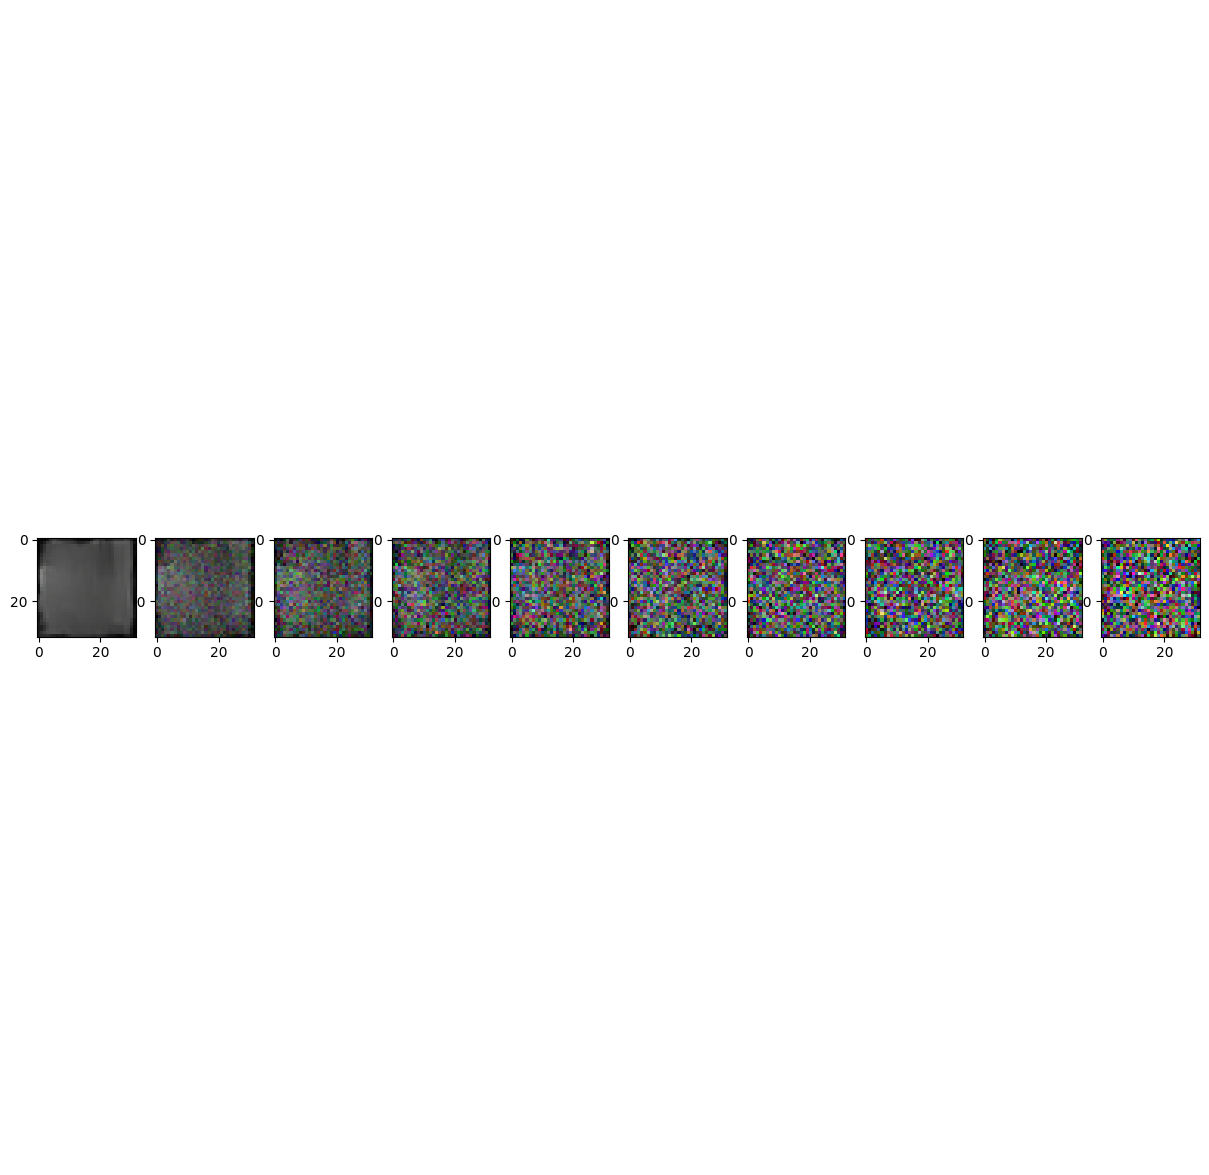


Starting Epoch 3/20
Epoch 3 | Step 0 | Loss: 0.0949
Epoch 3 | Step 100 | Loss: 0.1014
Epoch 3 | Step 200 | Loss: 0.1000
Epoch 3 | Step 300 | Loss: 0.1008
Epoch 3 | Step 400 | Loss: 0.0936
Epoch 3 | Step 500 | Loss: 0.1041
Epoch 3 | Step 600 | Loss: 0.1047
Epoch 3 | Step 700 | Loss: 0.1009
Epoch 3 | Step 800 | Loss: 0.0945
Epoch 3 | Step 900 | Loss: 0.0901
Epoch 3 | Step 1000 | Loss: 0.0842


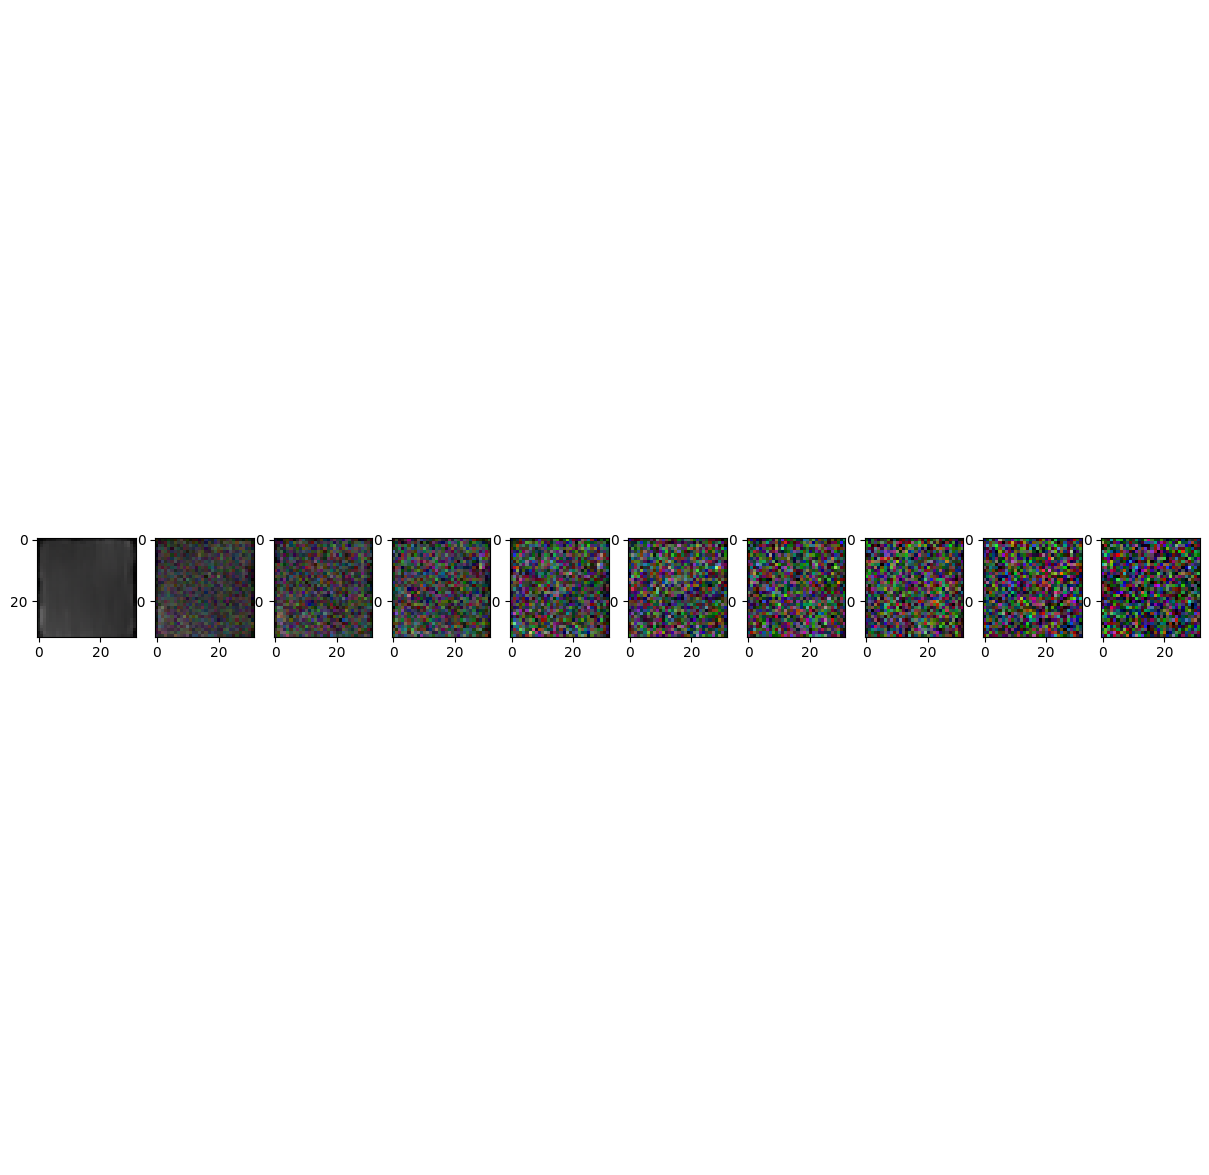


Starting Epoch 4/20
Epoch 4 | Step 0 | Loss: 0.1105
Epoch 4 | Step 100 | Loss: 0.1134
Epoch 4 | Step 200 | Loss: 0.0920
Epoch 4 | Step 300 | Loss: 0.1171
Epoch 4 | Step 400 | Loss: 0.0930
Epoch 4 | Step 500 | Loss: 0.0934
Epoch 4 | Step 600 | Loss: 0.0861
Epoch 4 | Step 700 | Loss: 0.0920
Epoch 4 | Step 800 | Loss: 0.0988
Epoch 4 | Step 900 | Loss: 0.0808
Epoch 4 | Step 1000 | Loss: 0.0852


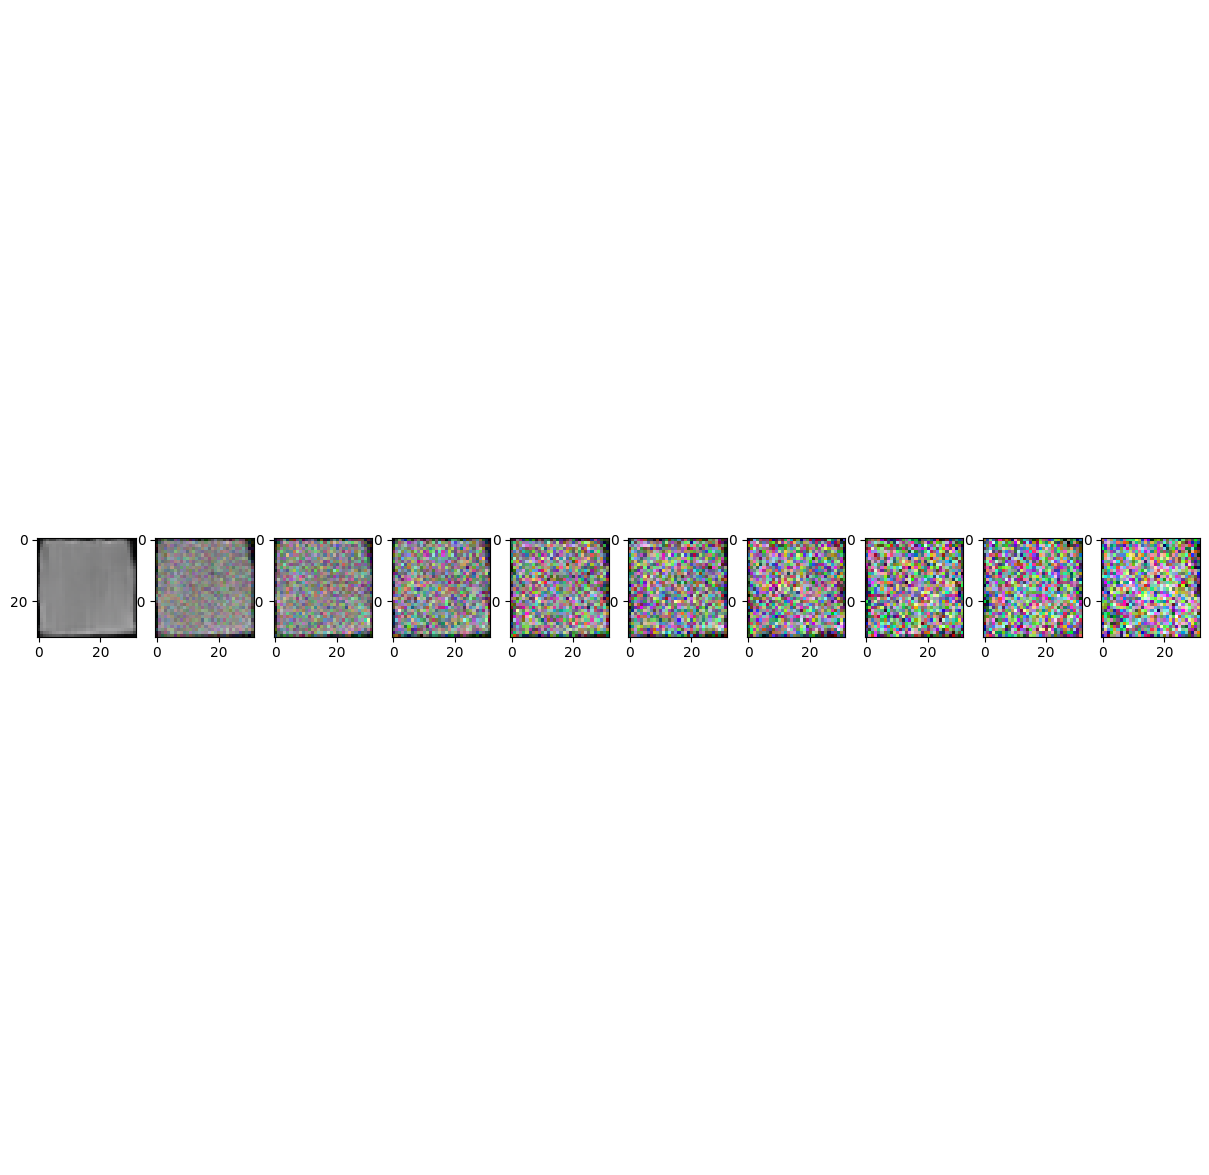


Starting Epoch 5/20
Epoch 5 | Step 0 | Loss: 0.1009
Epoch 5 | Step 100 | Loss: 0.0904
Epoch 5 | Step 200 | Loss: 0.1038
Epoch 5 | Step 300 | Loss: 0.0864
Epoch 5 | Step 400 | Loss: 0.0946
Epoch 5 | Step 500 | Loss: 0.0853
Epoch 5 | Step 600 | Loss: 0.0879
Epoch 5 | Step 700 | Loss: 0.0943
Epoch 5 | Step 800 | Loss: 0.0922
Epoch 5 | Step 900 | Loss: 0.0958
Epoch 5 | Step 1000 | Loss: 0.1026


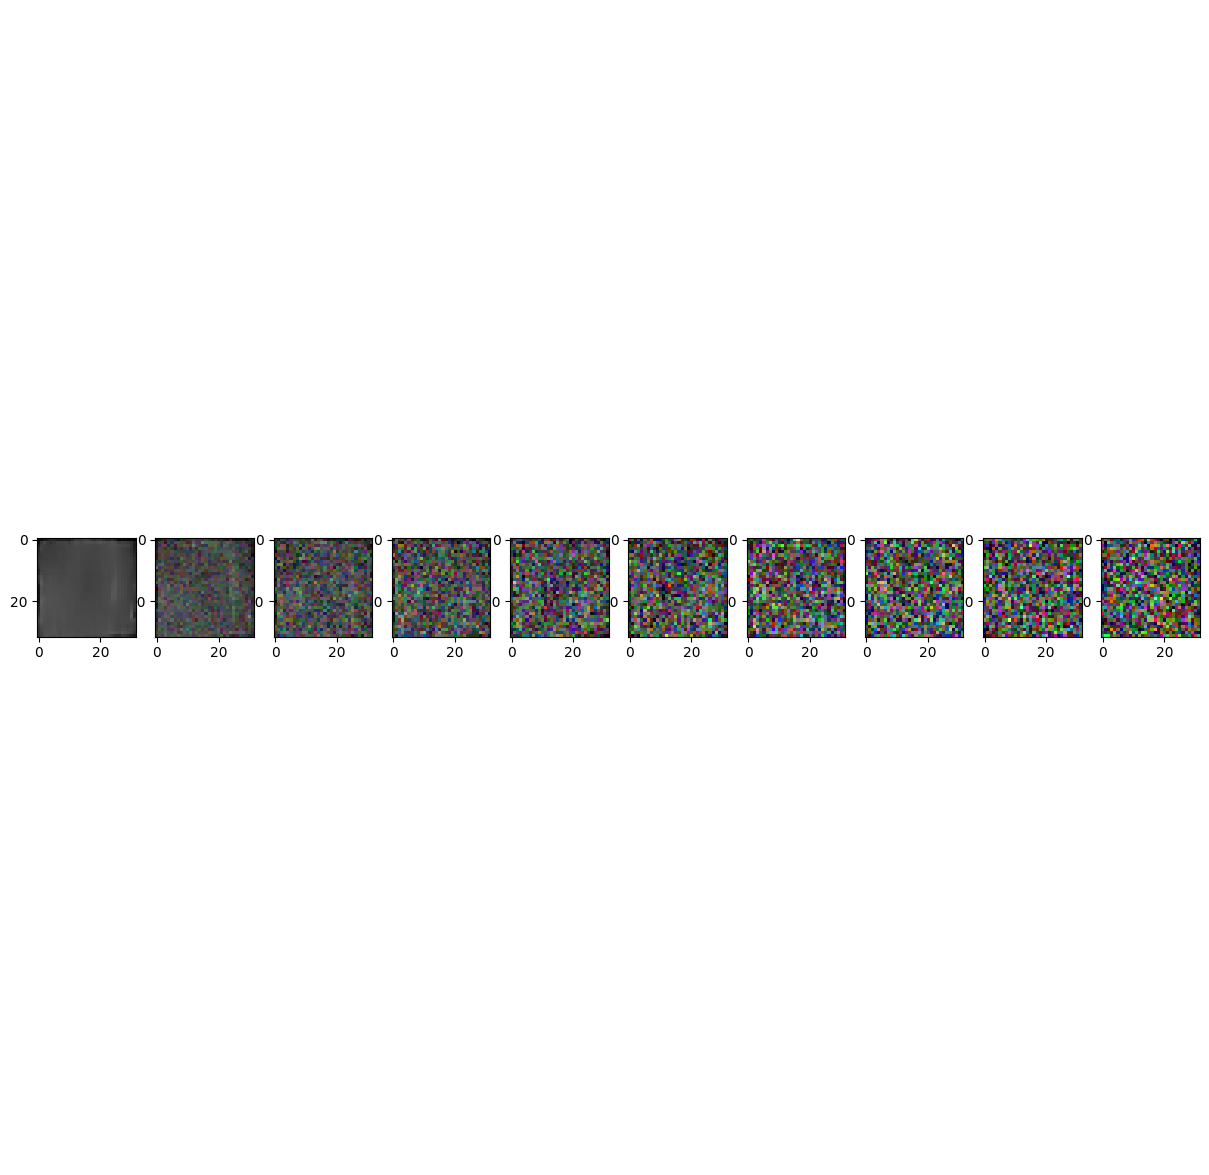


Starting Epoch 6/20
Epoch 6 | Step 0 | Loss: 0.0945
Epoch 6 | Step 100 | Loss: 0.0805
Epoch 6 | Step 200 | Loss: 0.0960
Epoch 6 | Step 300 | Loss: 0.0957
Epoch 6 | Step 400 | Loss: 0.0887
Epoch 6 | Step 500 | Loss: 0.0889
Epoch 6 | Step 600 | Loss: 0.0855
Epoch 6 | Step 700 | Loss: 0.0984
Epoch 6 | Step 800 | Loss: 0.0909
Epoch 6 | Step 900 | Loss: 0.0957
Epoch 6 | Step 1000 | Loss: 0.0906


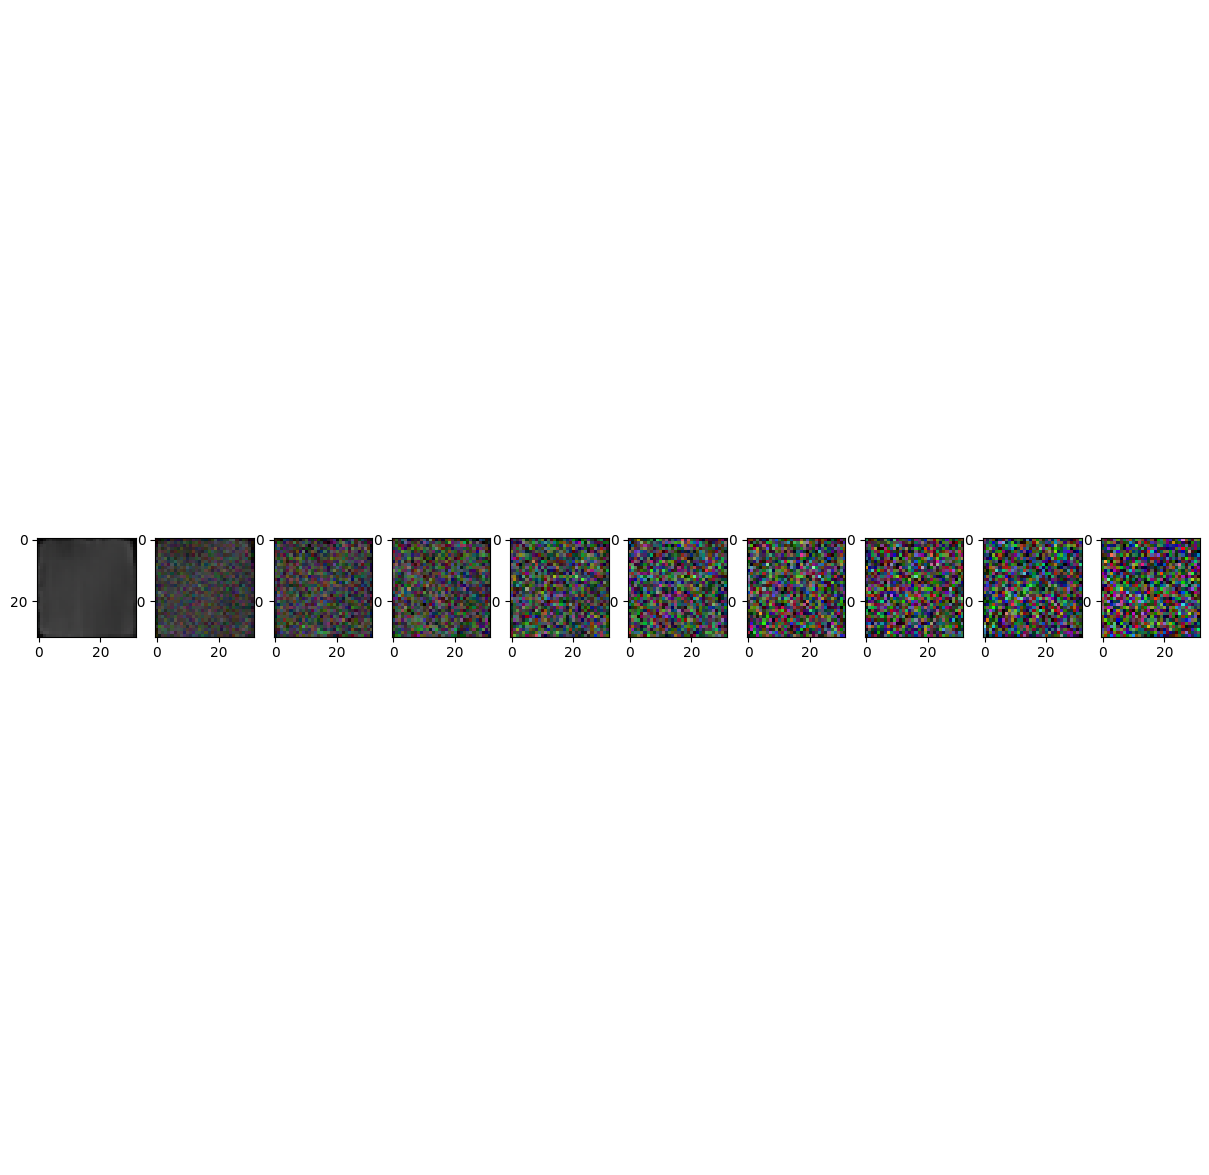


Starting Epoch 7/20
Epoch 7 | Step 0 | Loss: 0.0972
Epoch 7 | Step 100 | Loss: 0.0923
Epoch 7 | Step 200 | Loss: 0.0919
Epoch 7 | Step 300 | Loss: 0.0905
Epoch 7 | Step 400 | Loss: 0.0825
Epoch 7 | Step 500 | Loss: 0.0866
Epoch 7 | Step 600 | Loss: 0.0886
Epoch 7 | Step 700 | Loss: 0.0890
Epoch 7 | Step 800 | Loss: 0.0739
Epoch 7 | Step 900 | Loss: 0.0826
Epoch 7 | Step 1000 | Loss: 0.0733


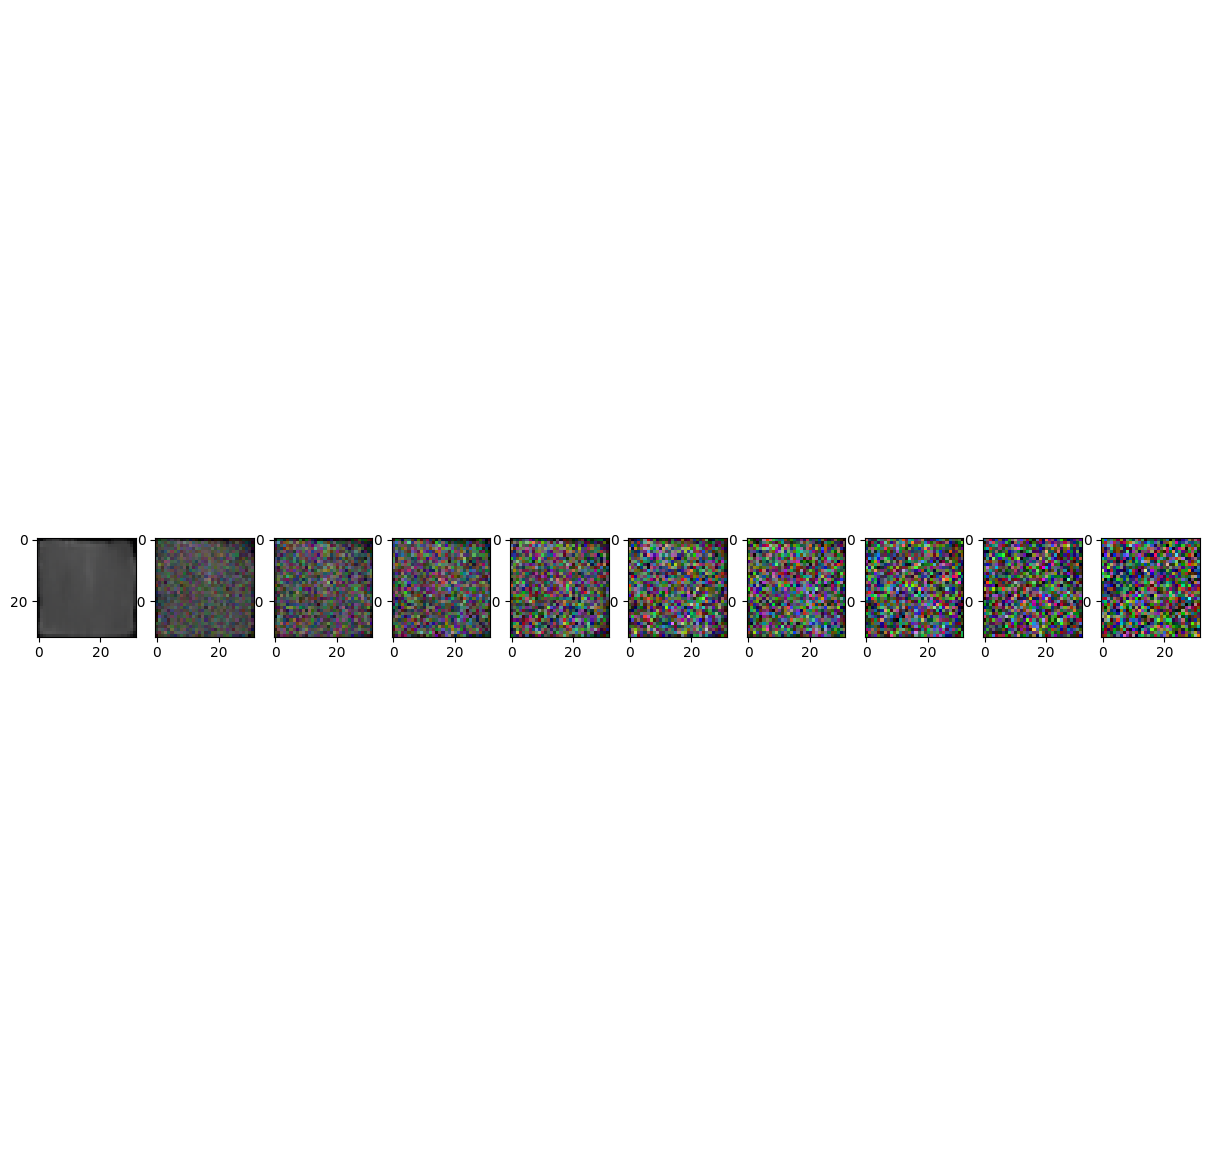


Starting Epoch 8/20
Epoch 8 | Step 0 | Loss: 0.0929
Epoch 8 | Step 100 | Loss: 0.0941
Epoch 8 | Step 200 | Loss: 0.0859
Epoch 8 | Step 300 | Loss: 0.0827
Epoch 8 | Step 400 | Loss: 0.1033
Epoch 8 | Step 500 | Loss: 0.0953
Epoch 8 | Step 600 | Loss: 0.0938
Epoch 8 | Step 700 | Loss: 0.0791
Epoch 8 | Step 800 | Loss: 0.0861
Epoch 8 | Step 900 | Loss: 0.0875
Epoch 8 | Step 1000 | Loss: 0.0940


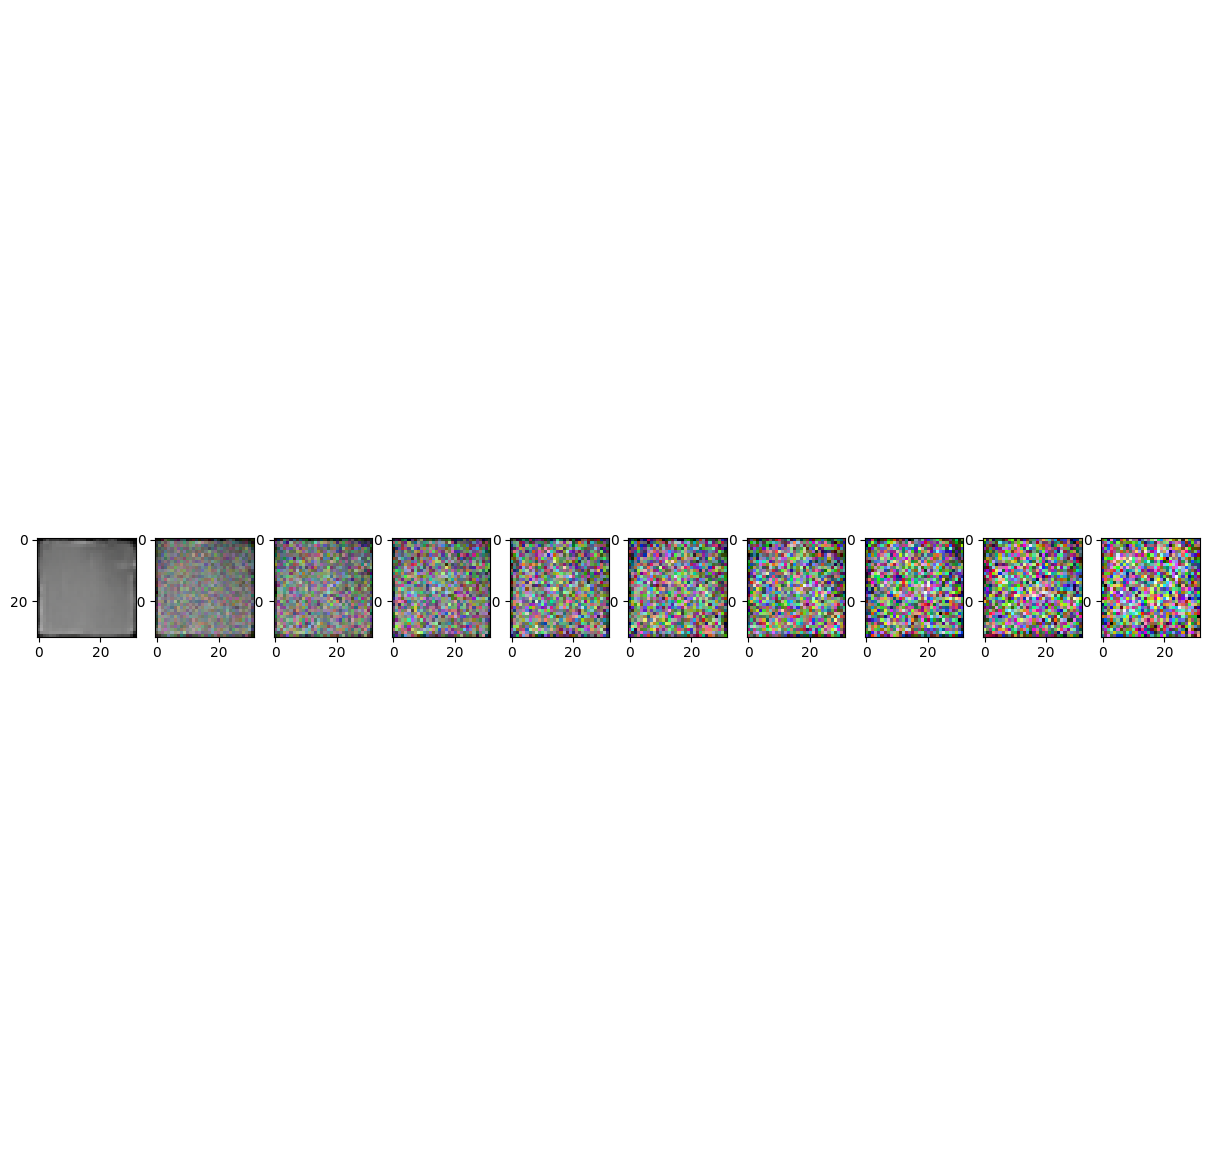


Starting Epoch 9/20
Epoch 9 | Step 0 | Loss: 0.0988
Epoch 9 | Step 100 | Loss: 0.0766
Epoch 9 | Step 200 | Loss: 0.0820
Epoch 9 | Step 300 | Loss: 0.0928
Epoch 9 | Step 400 | Loss: 0.0925
Epoch 9 | Step 500 | Loss: 0.0988
Epoch 9 | Step 600 | Loss: 0.1003
Epoch 9 | Step 700 | Loss: 0.0883
Epoch 9 | Step 800 | Loss: 0.0853
Epoch 9 | Step 900 | Loss: 0.0898
Epoch 9 | Step 1000 | Loss: 0.0826


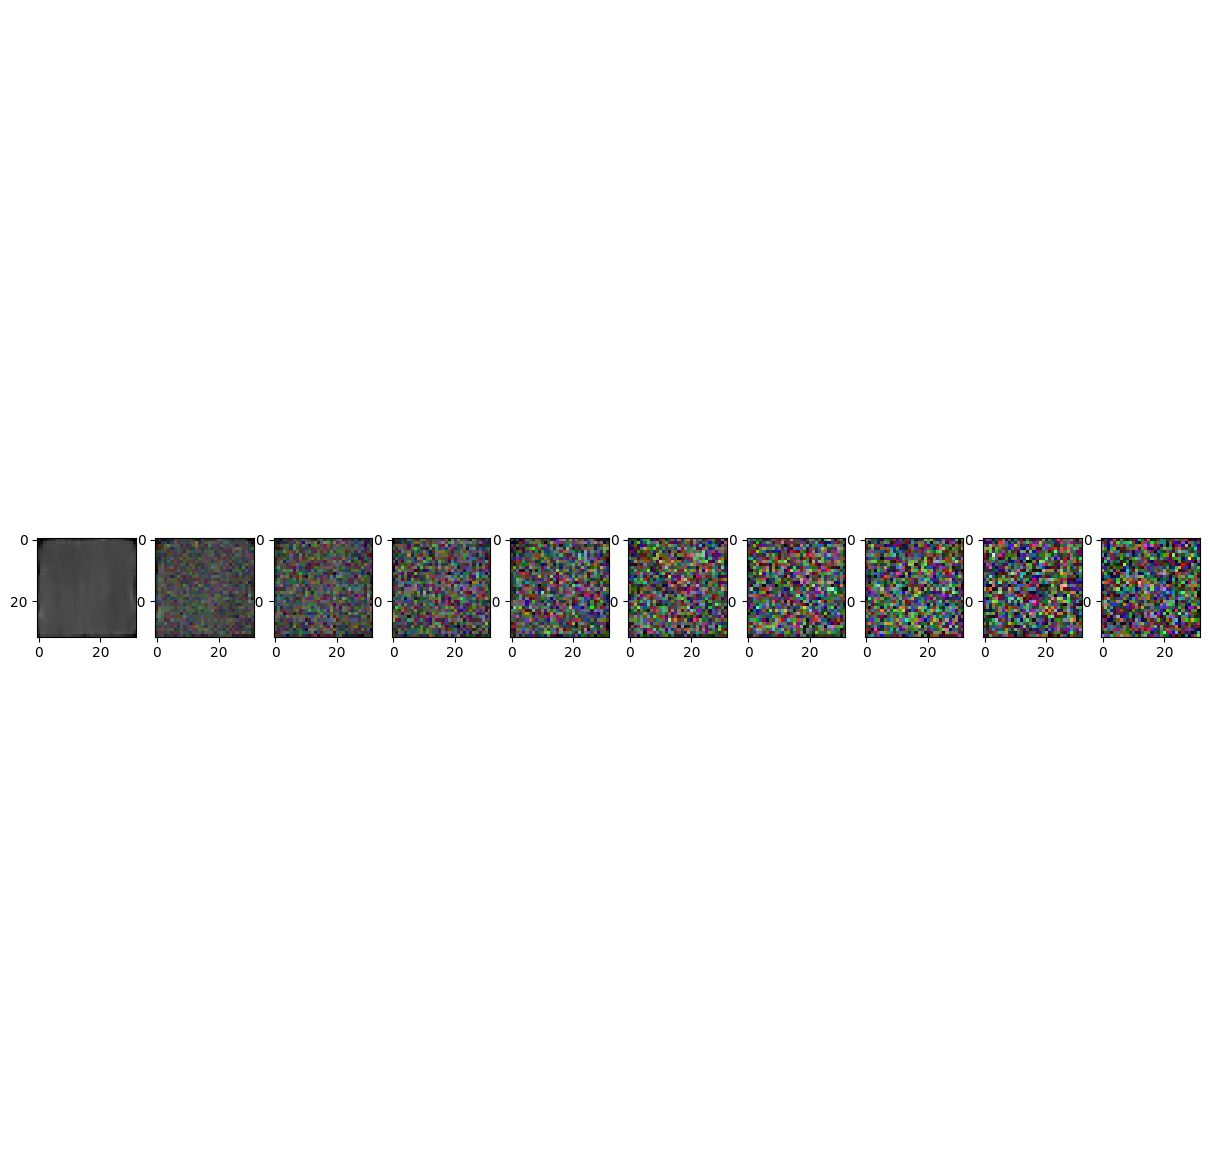


Starting Epoch 10/20
Epoch 10 | Step 0 | Loss: 0.0919
Epoch 10 | Step 100 | Loss: 0.0778
Epoch 10 | Step 200 | Loss: 0.0861
Epoch 10 | Step 300 | Loss: 0.0844
Epoch 10 | Step 400 | Loss: 0.0892
Epoch 10 | Step 500 | Loss: 0.0868
Epoch 10 | Step 600 | Loss: 0.0804
Epoch 10 | Step 700 | Loss: 0.0781
Epoch 10 | Step 800 | Loss: 0.0871
Epoch 10 | Step 900 | Loss: 0.0926
Epoch 10 | Step 1000 | Loss: 0.0808


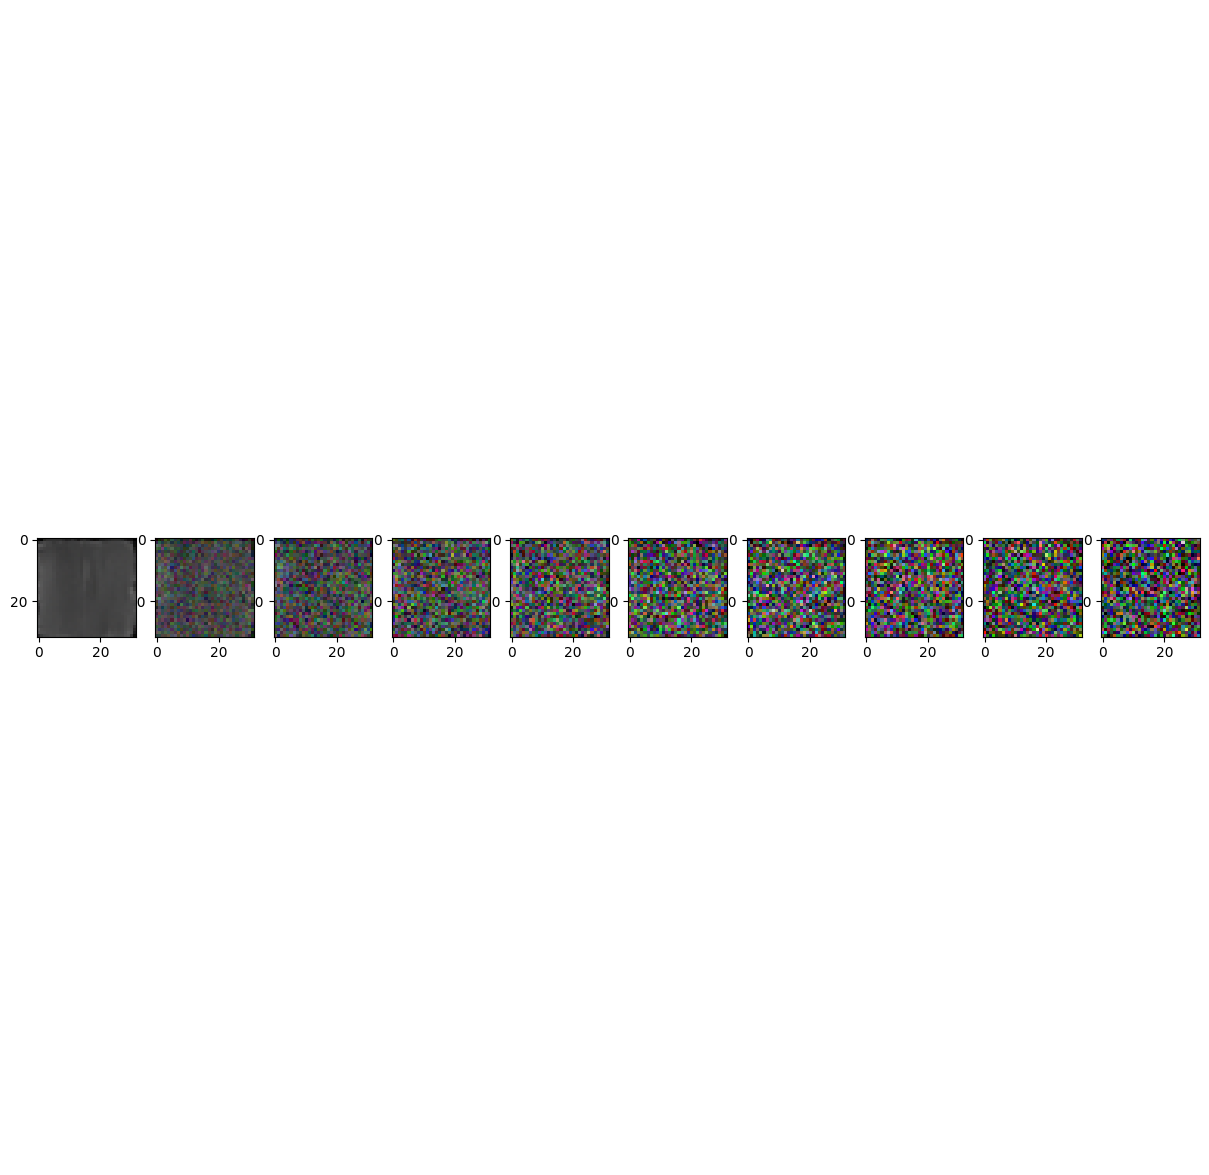


Starting Epoch 11/20
Epoch 11 | Step 0 | Loss: 0.0767
Epoch 11 | Step 100 | Loss: 0.0868
Epoch 11 | Step 200 | Loss: 0.0881
Epoch 11 | Step 300 | Loss: 0.0773
Epoch 11 | Step 400 | Loss: 0.0823
Epoch 11 | Step 500 | Loss: 0.0831
Epoch 11 | Step 600 | Loss: 0.0896
Epoch 11 | Step 700 | Loss: 0.0951
Epoch 11 | Step 800 | Loss: 0.0851
Epoch 11 | Step 900 | Loss: 0.0909
Epoch 11 | Step 1000 | Loss: 0.0852


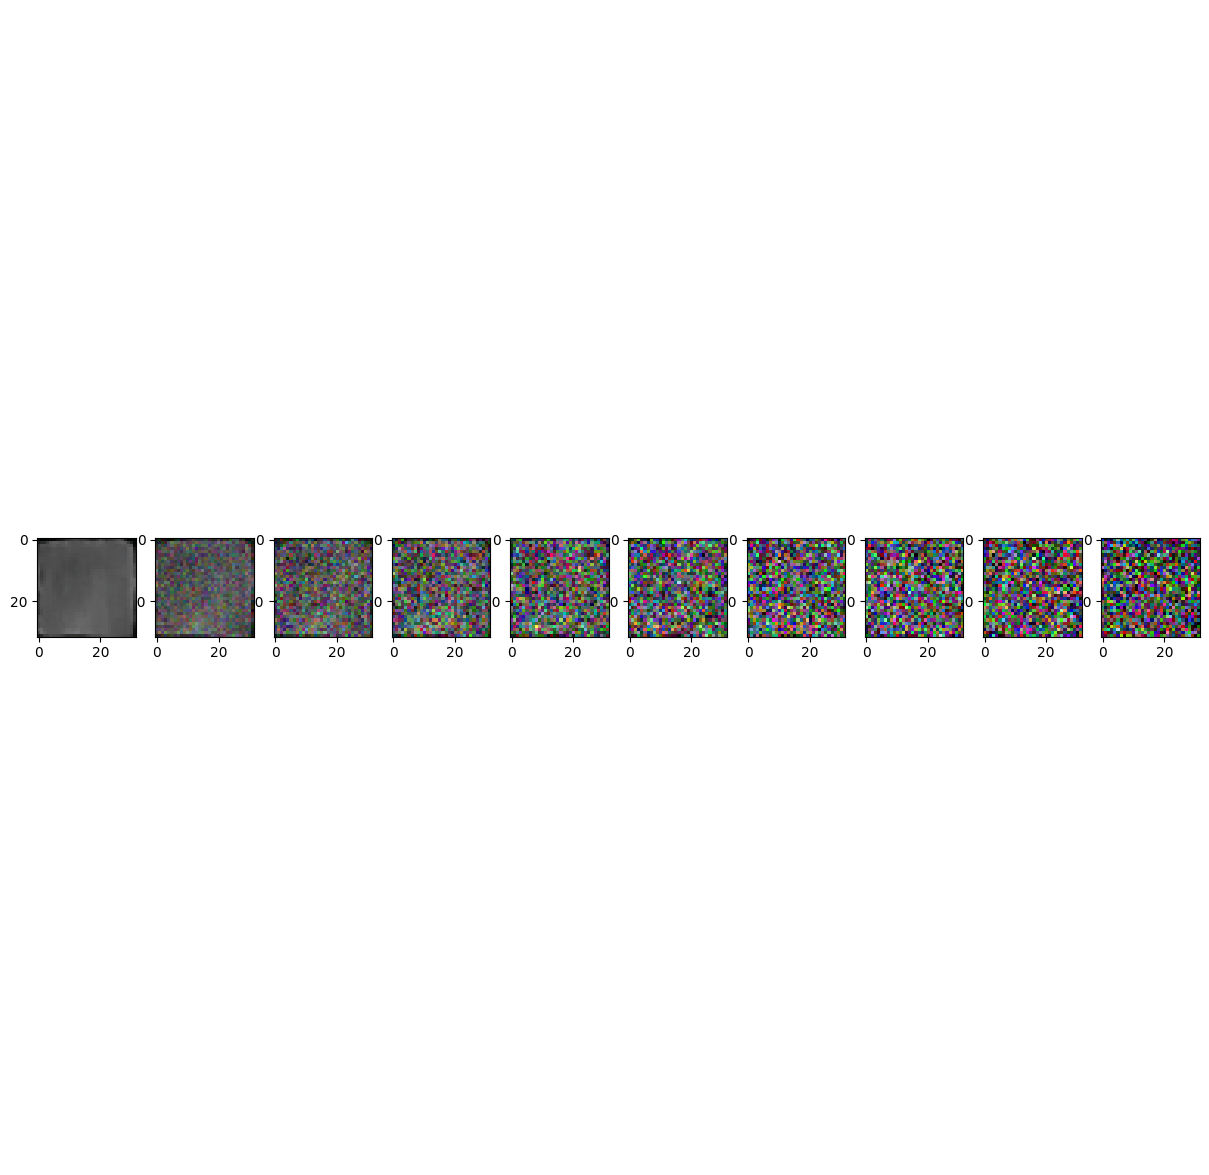


Starting Epoch 12/20
Epoch 12 | Step 0 | Loss: 0.0837
Epoch 12 | Step 100 | Loss: 0.0901
Epoch 12 | Step 200 | Loss: 0.0889
Epoch 12 | Step 300 | Loss: 0.0821
Epoch 12 | Step 400 | Loss: 0.0824
Epoch 12 | Step 500 | Loss: 0.0745
Epoch 12 | Step 600 | Loss: 0.0692
Epoch 12 | Step 700 | Loss: 0.0847
Epoch 12 | Step 800 | Loss: 0.0864
Epoch 12 | Step 900 | Loss: 0.0819
Epoch 12 | Step 1000 | Loss: 0.0827


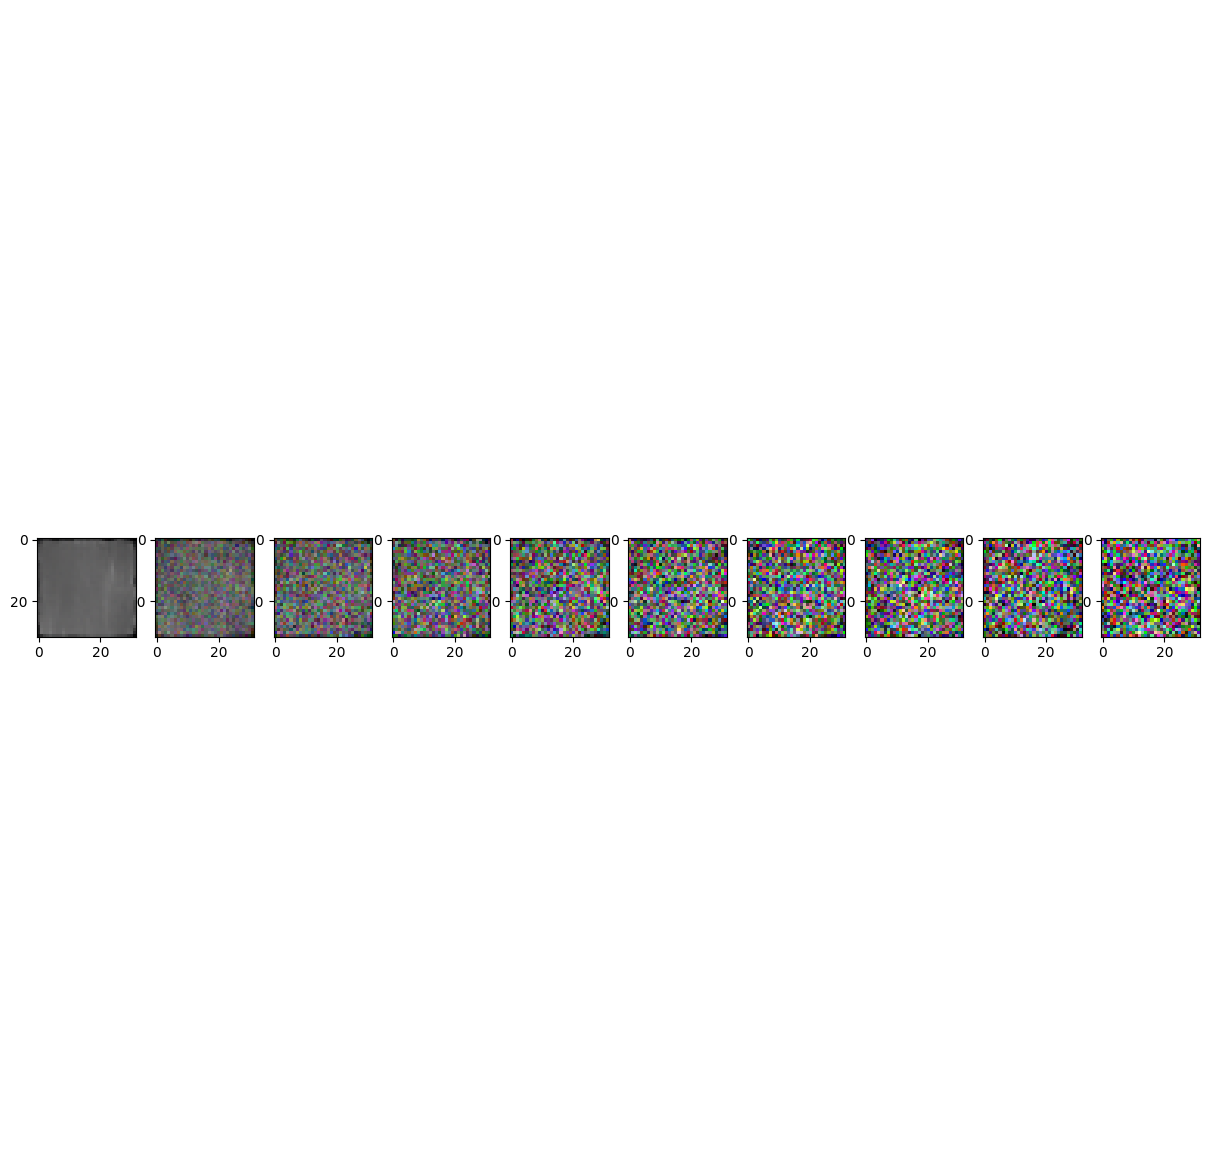


Starting Epoch 13/20
Epoch 13 | Step 0 | Loss: 0.0877
Epoch 13 | Step 100 | Loss: 0.0842
Epoch 13 | Step 200 | Loss: 0.0903
Epoch 13 | Step 300 | Loss: 0.0993
Epoch 13 | Step 400 | Loss: 0.0771
Epoch 13 | Step 500 | Loss: 0.0834
Epoch 13 | Step 600 | Loss: 0.0885
Epoch 13 | Step 700 | Loss: 0.0858
Epoch 13 | Step 800 | Loss: 0.0794
Epoch 13 | Step 900 | Loss: 0.0863
Epoch 13 | Step 1000 | Loss: 0.0790


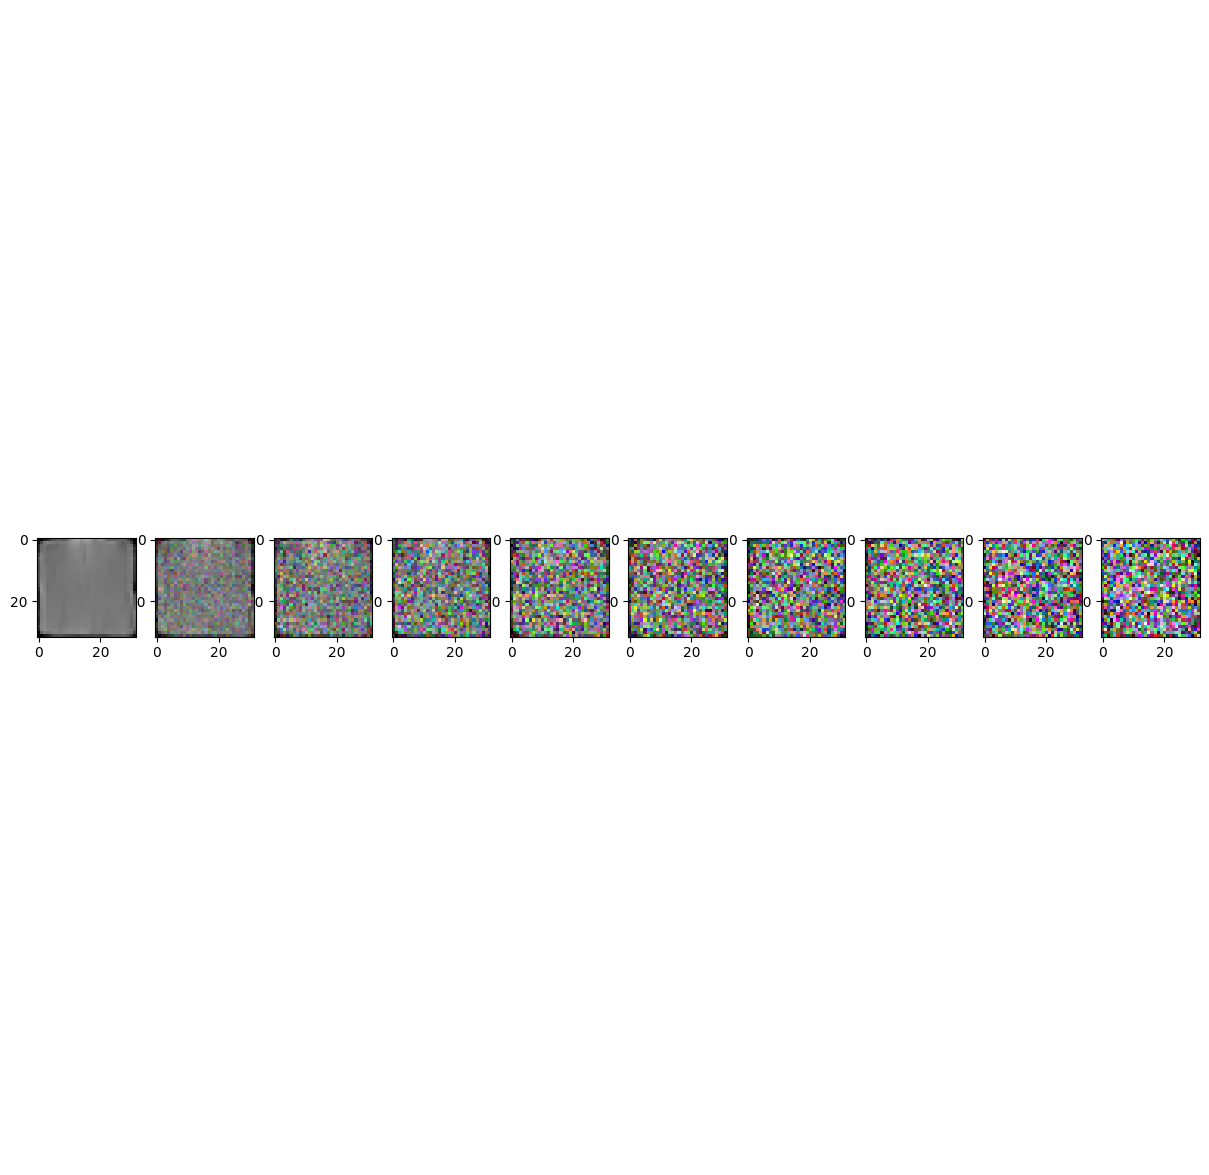


Starting Epoch 14/20
Epoch 14 | Step 0 | Loss: 0.0874
Epoch 14 | Step 100 | Loss: 0.0802
Epoch 14 | Step 200 | Loss: 0.0890
Epoch 14 | Step 300 | Loss: 0.0757
Epoch 14 | Step 400 | Loss: 0.0835
Epoch 14 | Step 500 | Loss: 0.0902
Epoch 14 | Step 600 | Loss: 0.0880
Epoch 14 | Step 700 | Loss: 0.0815
Epoch 14 | Step 800 | Loss: 0.0801
Epoch 14 | Step 900 | Loss: 0.0877
Epoch 14 | Step 1000 | Loss: 0.0851


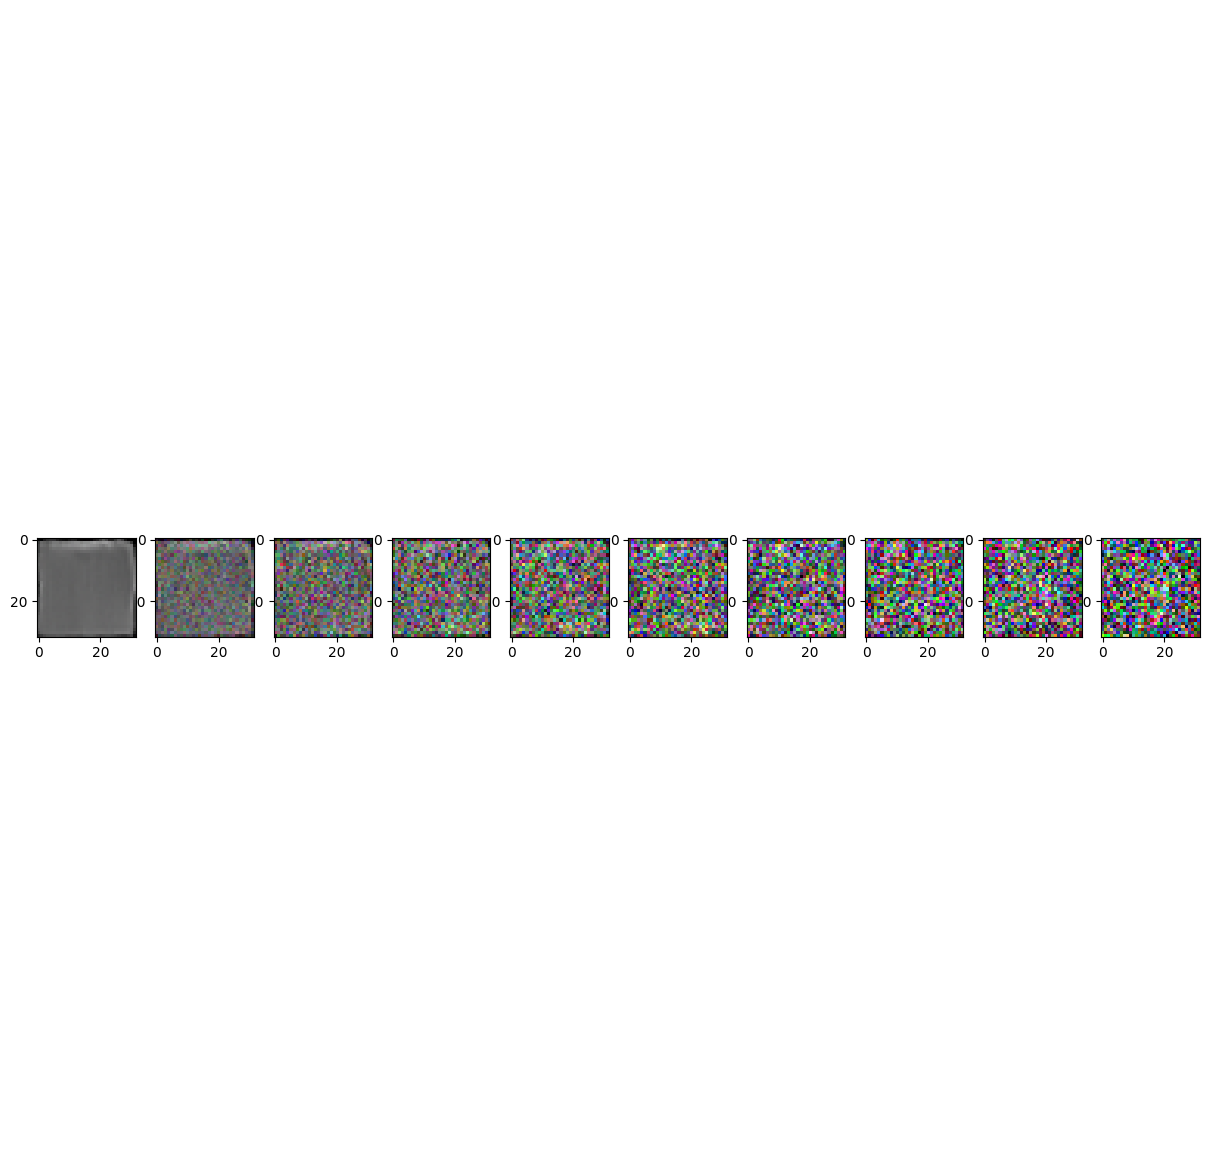


Starting Epoch 15/20
Epoch 15 | Step 0 | Loss: 0.0820
Epoch 15 | Step 100 | Loss: 0.0698
Epoch 15 | Step 200 | Loss: 0.0867
Epoch 15 | Step 300 | Loss: 0.0783
Epoch 15 | Step 400 | Loss: 0.0754
Epoch 15 | Step 500 | Loss: 0.0753
Epoch 15 | Step 600 | Loss: 0.0715
Epoch 15 | Step 700 | Loss: 0.0760
Epoch 15 | Step 800 | Loss: 0.0798
Epoch 15 | Step 900 | Loss: 0.0813
Epoch 15 | Step 1000 | Loss: 0.0706


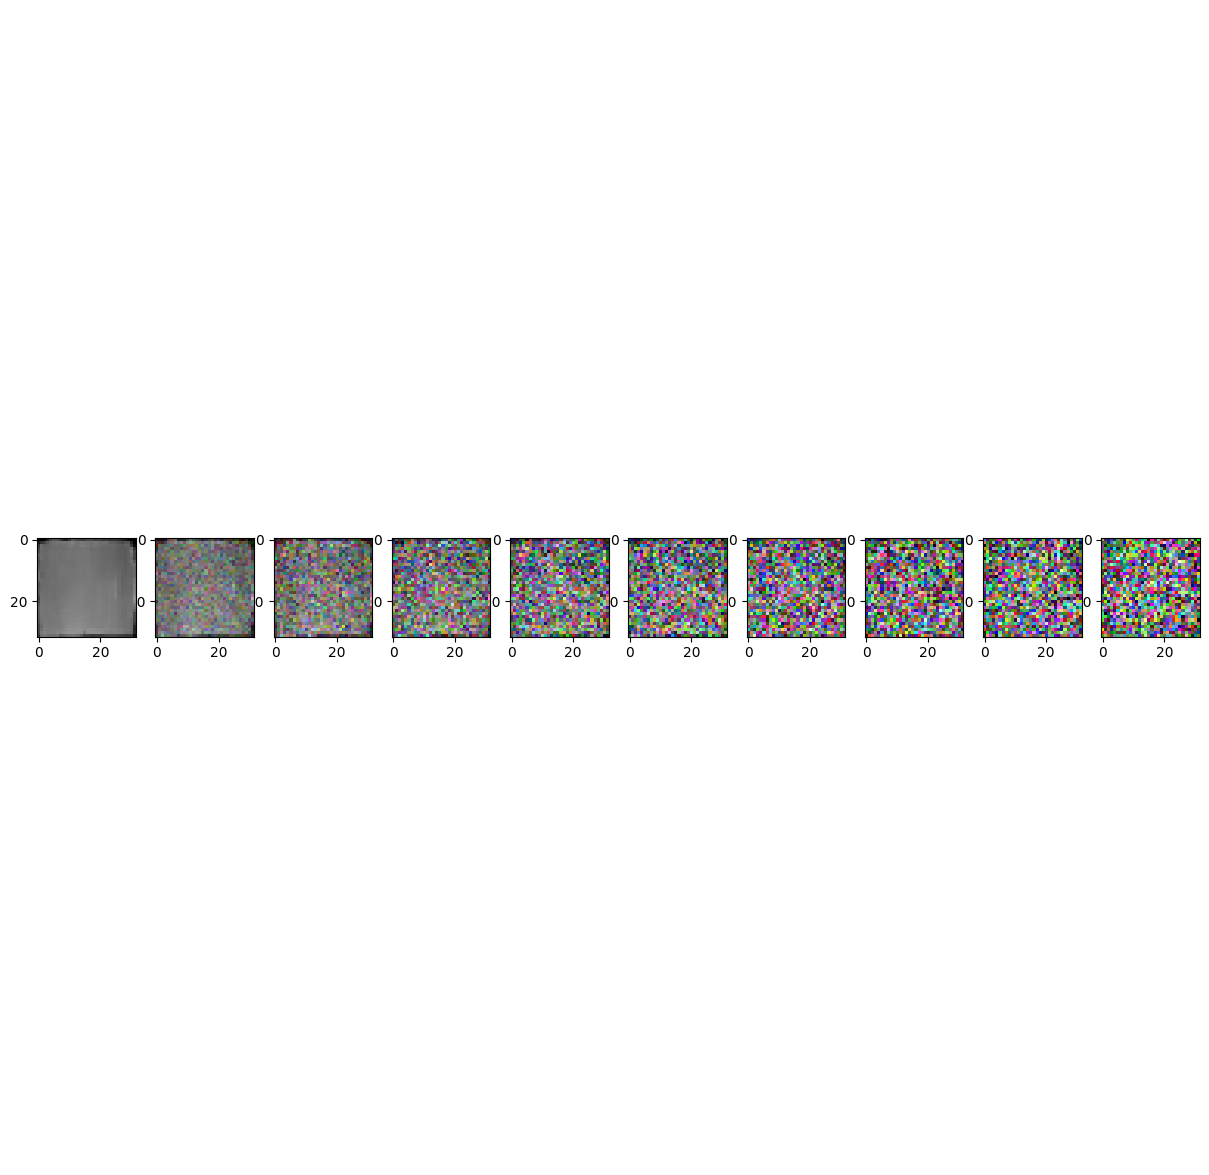


Starting Epoch 16/20
Epoch 16 | Step 0 | Loss: 0.0779
Epoch 16 | Step 100 | Loss: 0.0886
Epoch 16 | Step 200 | Loss: 0.0870
Epoch 16 | Step 300 | Loss: 0.0885
Epoch 16 | Step 400 | Loss: 0.0908
Epoch 16 | Step 500 | Loss: 0.1041
Epoch 16 | Step 600 | Loss: 0.0886
Epoch 16 | Step 700 | Loss: 0.0716
Epoch 16 | Step 800 | Loss: 0.0956
Epoch 16 | Step 900 | Loss: 0.0746
Epoch 16 | Step 1000 | Loss: 0.0762


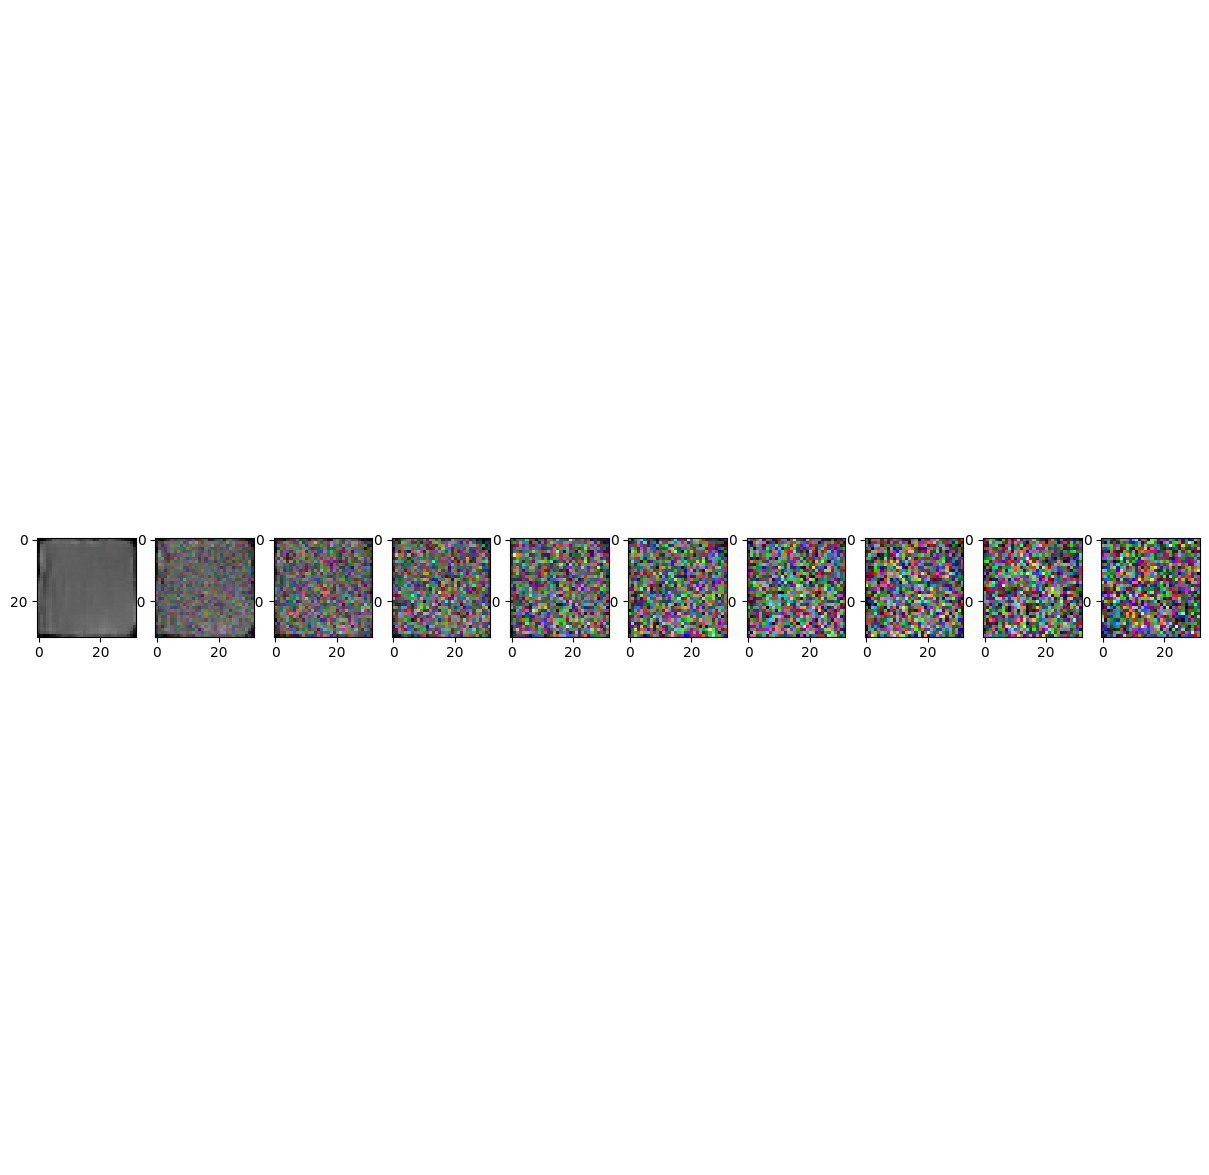


Starting Epoch 17/20
Epoch 17 | Step 0 | Loss: 0.0710
Epoch 17 | Step 100 | Loss: 0.0794
Epoch 17 | Step 200 | Loss: 0.0833
Epoch 17 | Step 300 | Loss: 0.0737
Epoch 17 | Step 400 | Loss: 0.0790
Epoch 17 | Step 500 | Loss: 0.0848
Epoch 17 | Step 600 | Loss: 0.0714
Epoch 17 | Step 700 | Loss: 0.0845
Epoch 17 | Step 800 | Loss: 0.0798
Epoch 17 | Step 900 | Loss: 0.0796
Epoch 17 | Step 1000 | Loss: 0.0879


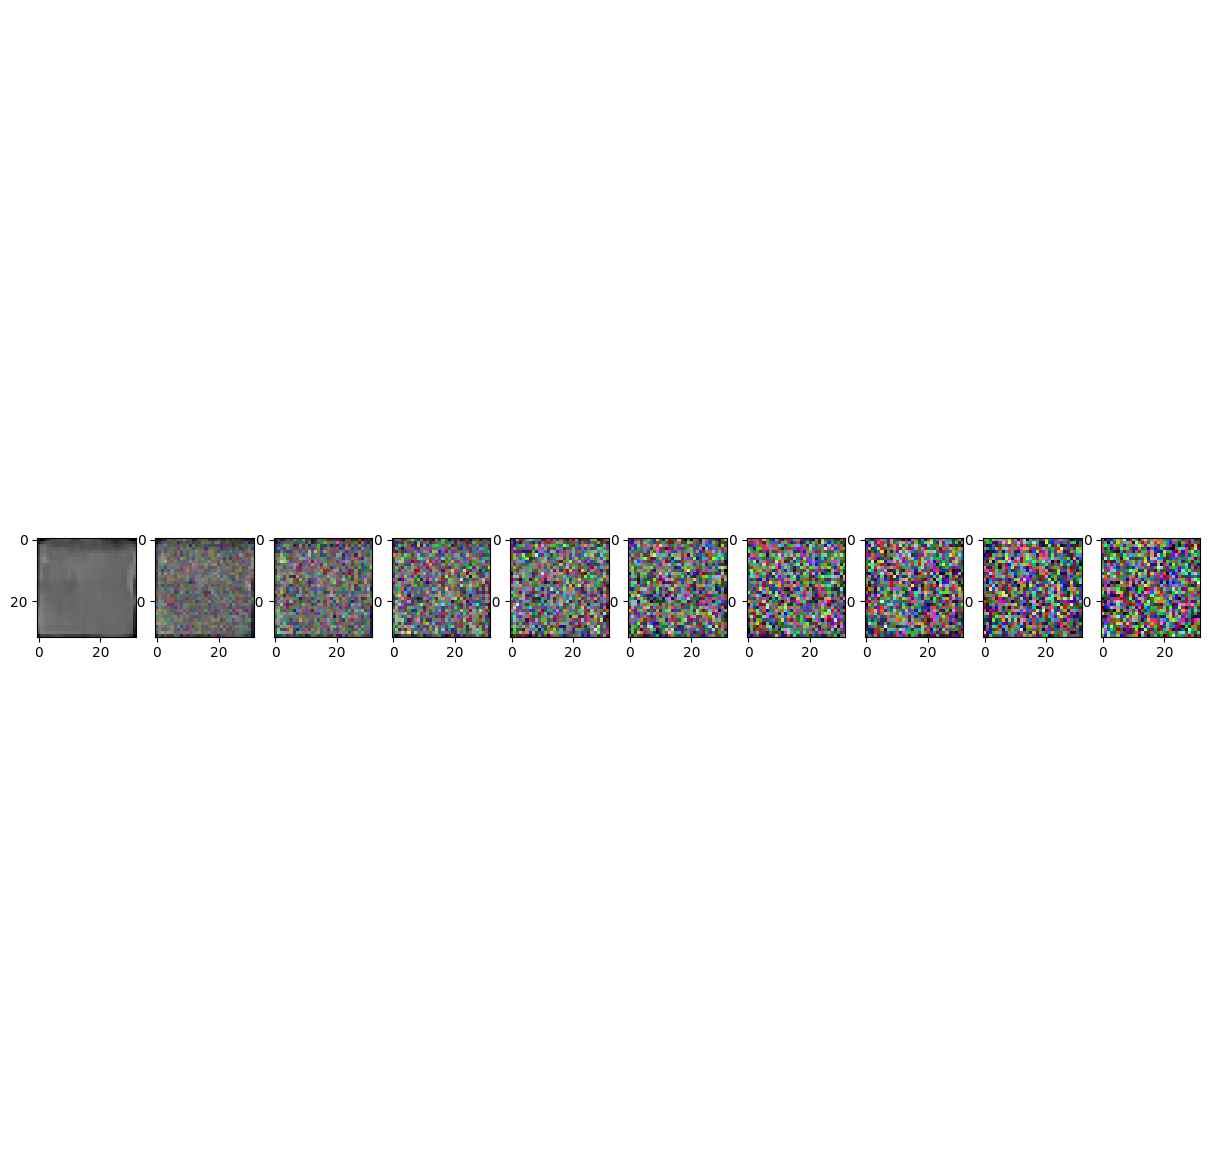


Starting Epoch 18/20
Epoch 18 | Step 0 | Loss: 0.0840
Epoch 18 | Step 100 | Loss: 0.0849
Epoch 18 | Step 200 | Loss: 0.0777
Epoch 18 | Step 300 | Loss: 0.0740
Epoch 18 | Step 400 | Loss: 0.0680
Epoch 18 | Step 500 | Loss: 0.0895
Epoch 18 | Step 600 | Loss: 0.0896
Epoch 18 | Step 700 | Loss: 0.0738
Epoch 18 | Step 800 | Loss: 0.0836
Epoch 18 | Step 900 | Loss: 0.0868
Epoch 18 | Step 1000 | Loss: 0.0913


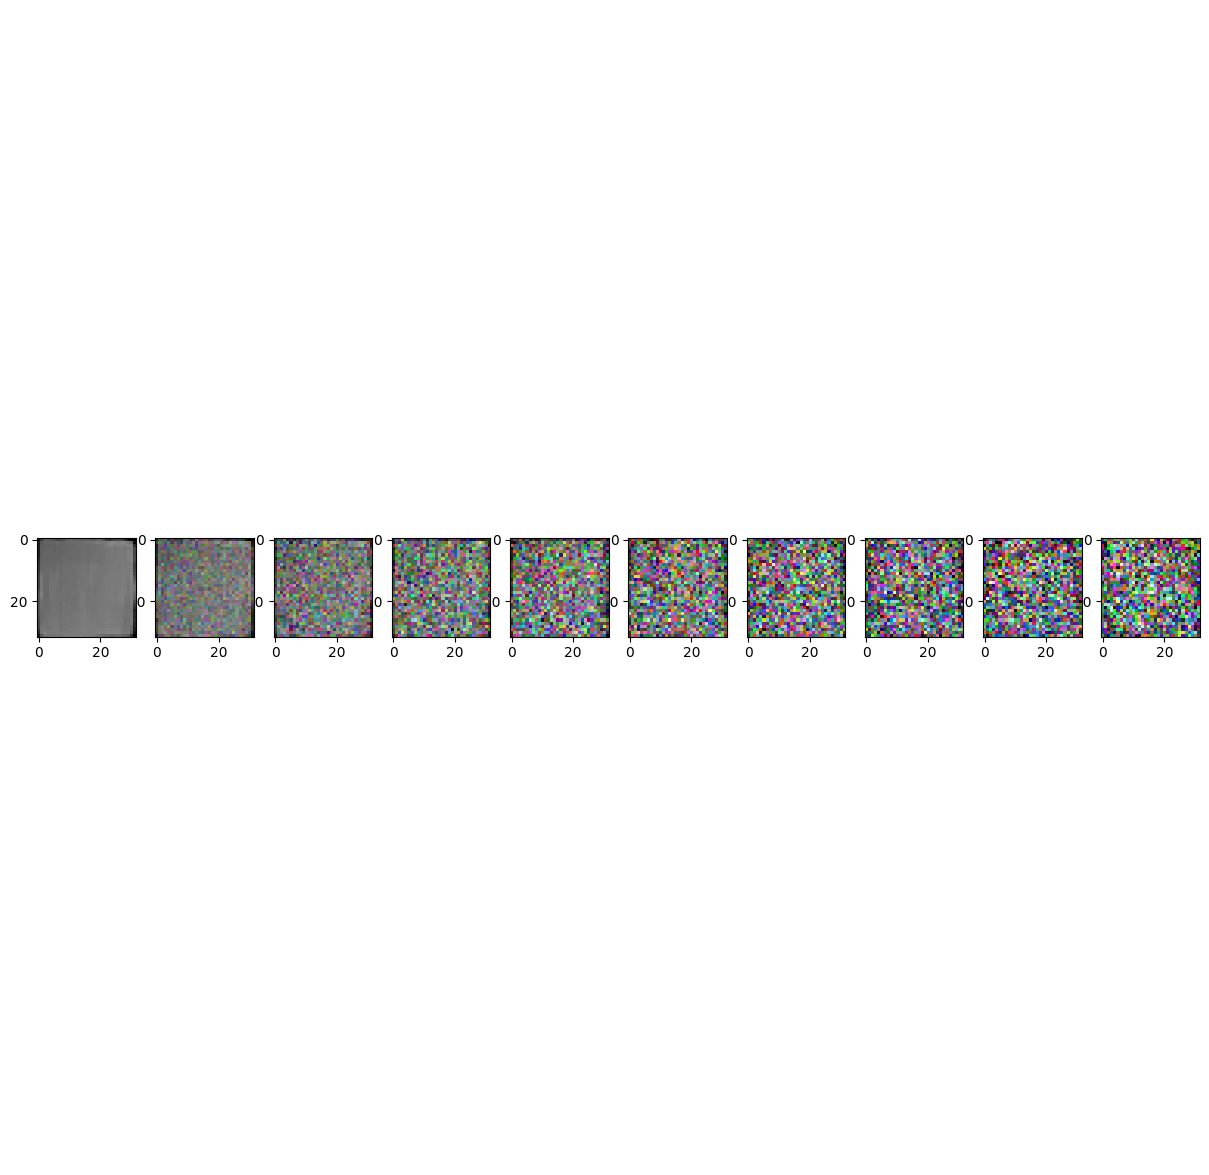


Starting Epoch 19/20
Epoch 19 | Step 0 | Loss: 0.0889
Epoch 19 | Step 100 | Loss: 0.0980
Epoch 19 | Step 200 | Loss: 0.1015
Epoch 19 | Step 300 | Loss: 0.0780
Epoch 19 | Step 400 | Loss: 0.0735
Epoch 19 | Step 500 | Loss: 0.0905
Epoch 19 | Step 600 | Loss: 0.0839
Epoch 19 | Step 700 | Loss: 0.0762
Epoch 19 | Step 800 | Loss: 0.0697
Epoch 19 | Step 900 | Loss: 0.0760
Epoch 19 | Step 1000 | Loss: 0.0739


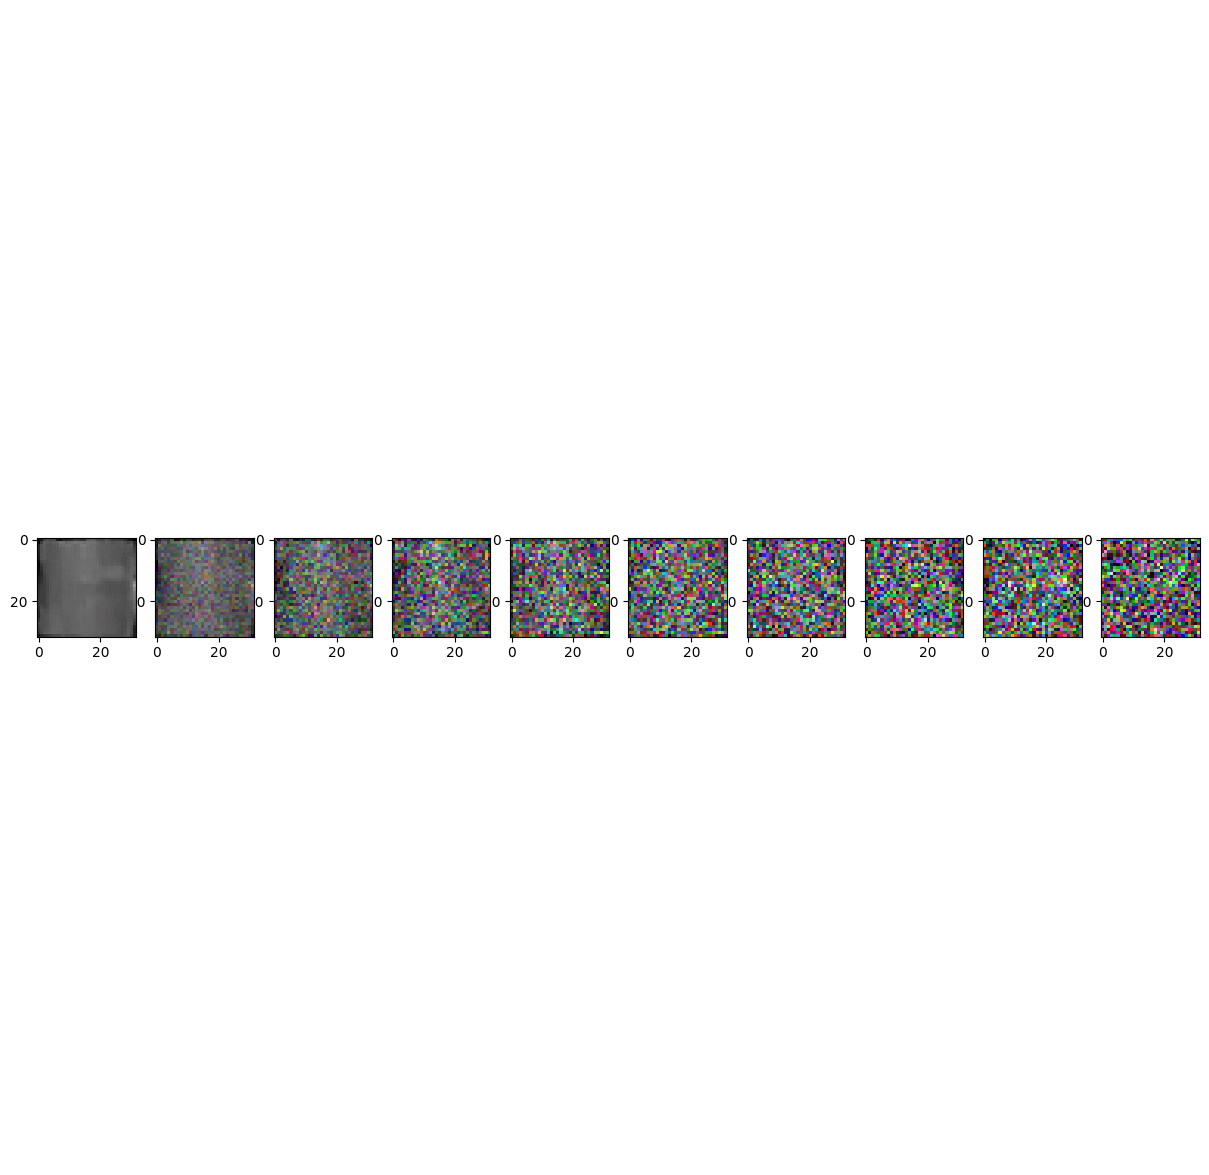


Starting Epoch 20/20
Epoch 20 | Step 0 | Loss: 0.0784
Epoch 20 | Step 100 | Loss: 0.0922
Epoch 20 | Step 200 | Loss: 0.0819
Epoch 20 | Step 300 | Loss: 0.0696
Epoch 20 | Step 400 | Loss: 0.0742
Epoch 20 | Step 500 | Loss: 0.0796
Epoch 20 | Step 600 | Loss: 0.0843
Epoch 20 | Step 700 | Loss: 0.0796
Epoch 20 | Step 800 | Loss: 0.0861
Epoch 20 | Step 900 | Loss: 0.0662
Epoch 20 | Step 1000 | Loss: 0.0692


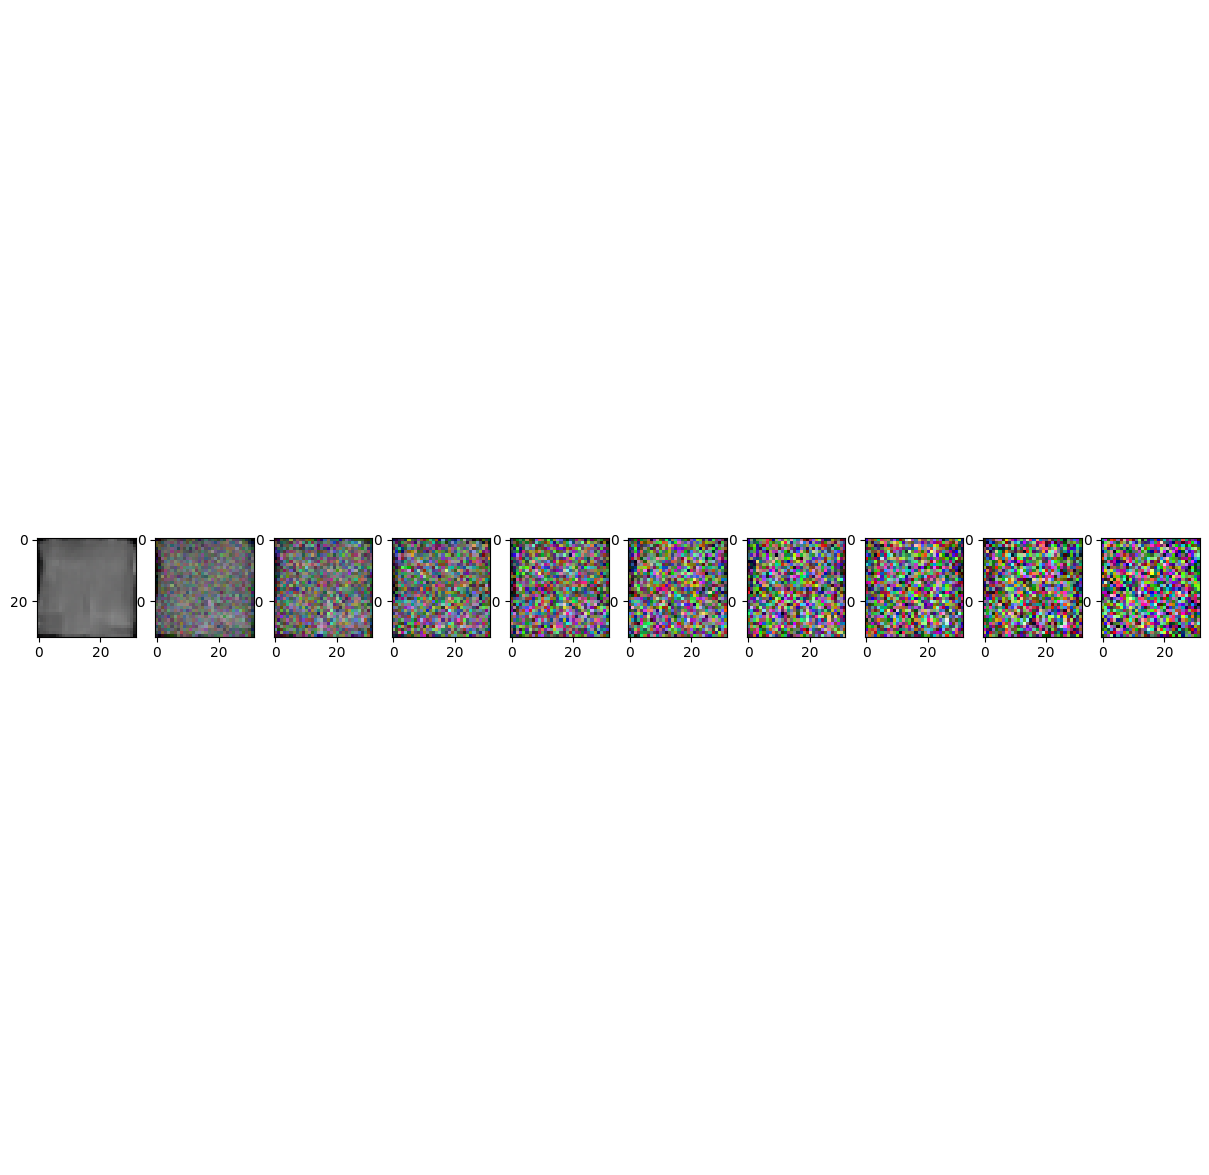

In [26]:
## Training

from torch.optim import Adam

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

optimizer = Adam(model.parameters(), lr=0.001)
epochs = 20

for epoch in range(epochs):
    print(f"\nStarting Epoch {epoch+1}/{epochs}")

    for step, batch in enumerate(dataloader):
        optimizer.zero_grad()

        t = torch.randint(0, T, (BATCH_SIZE,), device=device).long()
        loss = get_loss(model, batch[0].to(device), t)

        loss.backward()
        optimizer.step()


        if step % 100 == 0:
            print(f"Epoch {epoch+1} | Step {step} | Loss: {loss.item():.4f}")

    # sampling every epoch
    sample_plot_image()